# 02 — Third-order response validation

This notebook validates the direct mixed frequency-domain third-order
molecular response against an explicit time-domain calculation for the
coupled thermal dimer.

The time-domain response is

$$
R^{(3)}(t_3,T,t_1)
=
\langle\!\langle\mu|
e^{\mathcal{L}t_3}
V
e^{\mathcal{L}T}
V
e^{\mathcal{L}t_1}
V
|\rho_0\rangle\rangle,
$$

with

$$
t_1,t_3\ge0.
$$

Fourier transformation over the two coherence intervals gives

$$
M^{(3)}(\omega_3,T,\omega_1)
=
\int_0^\infty dt_3
\int_0^\infty dt_1\,
e^{i\omega_3t_3}
e^{i\omega_1t_1}
R^{(3)}(t_3,T,t_1).
$$

The direct frequency-domain expression is

$$
\boxed{
M^{(3)}(\omega_3,T,\omega_1)
=
\langle\!\langle\mu|
G(\omega_3)
V
e^{\mathcal{L}T}
V
G(\omega_1)
V
|\rho_0\rangle\rangle.
}
$$

The first objective is to verify numerically that

$$
\boxed{
M_{\mathrm{TD}}^{(3)}
(\omega_3,T,\omega_1)
=
M_{\mathrm{FD}}^{(3)}
(\omega_3,T,\omega_1)
}
$$

within numerical accuracy.

At this stage we use the full dipole-commutator interaction
superoperator $V$.  Rephasing/nonrephasing pathway decomposition and
rotating-wave approximations will be treated only after the total
third-order response has been validated.

In [100]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from scipy.linalg import expm
from numpy.linalg import norm

repo_root = Path.cwd().parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.dimer_model import (
    build_dimer,
    vec,
    unvec,
    stationary_state,
)

In [101]:
model = build_dimer()

H_S = model["H_S"]
mu = model["mu"]

L_super = model["L_super"]
V = model["V"]

rho0 = model["rho0"]

hbar = model["hbar"]

d = H_S.shape[0]
I16 = np.eye(d**2, dtype=complex)

rho0_vec = vec(rho0)
mu_bra = vec(mu).conj()

print("Hilbert dimension   =", d)
print("Liouville dimension =", d**2)
print("Tr(rho0)            =", np.trace(rho0))

Hilbert dimension   = 4
Liouville dimension = 16
Tr(rho0)            = (1+0j)


## 1. Constructing the third-order response step by step

Before constructing a two-dimensional $(t_1,t_3)$ grid, we evaluate the
third-order response at a single pair of time intervals.

Starting from the prepared state,

$$
|\rho_0\rangle\rangle,
$$

the first light--matter interaction produces

$$
|\rho^{(1)}(0)\rangle\rangle
=
V|\rho_0\rangle\rangle.
$$

The system then evolves during the first coherence interval $t_1$,

$$
|\rho^{(1)}(t_1)\rangle\rangle
=
e^{\mathcal{L}t_1}
V|\rho_0\rangle\rangle.
$$

The second interaction gives

$$
V
e^{\mathcal{L}t_1}
V|\rho_0\rangle\rangle,
$$

followed by evolution during the waiting time $T$,

$$
e^{\mathcal{L}T}
V
e^{\mathcal{L}t_1}
V|\rho_0\rangle\rangle.
$$

The third interaction then produces

$$
V
e^{\mathcal{L}T}
V
e^{\mathcal{L}t_1}
V|\rho_0\rangle\rangle,
$$

which evolves during the detection interval $t_3$.

Finally,

$$
\boxed{
R^{(3)}(t_3,T,t_1)
=
\langle\!\langle\mu|
e^{\mathcal{L}t_3}
V
e^{\mathcal{L}T}
V
e^{\mathcal{L}t_1}
V
|\rho_0\rangle\rangle.
}
$$

Because $V=(i/\hbar)[\mu,\cdot]$ is a commutator superoperator, each
light--matter interaction preserves zero trace of the perturbative
correction.  With the full Hermitian dipole operator used here,
the resulting perturbative operators also remain Hermitian, so the
dipole expectation value should be real up to numerical roundoff.

In [102]:
# Test time intervals
t1_test = 2.0
T_test = 5.0
t3_test = 3.0

# ------------------------------------------------------------
# First interaction
# ------------------------------------------------------------

rho_after_1 = V @ rho0_vec

# Evolution during t1
rho_after_t1 = (
    expm(L_super * t1_test)
    @ rho_after_1
)

# ------------------------------------------------------------
# Second interaction
# ------------------------------------------------------------

rho_after_2 = V @ rho_after_t1

# Evolution during waiting time T
rho_after_T = (
    expm(L_super * T_test)
    @ rho_after_2
)

# ------------------------------------------------------------
# Third interaction
# ------------------------------------------------------------

rho_after_3 = V @ rho_after_T

# Evolution during t3
rho_after_t3 = (
    expm(L_super * t3_test)
    @ rho_after_3
)

# Third-order response
R3_test = (
    mu_bra @ rho_after_t3
)

print(
    "R^(3)(t3=3, T=5, t1=2) =",
    R3_test
)

R^(3)(t3=3, T=5, t1=2) = (-6.308386928356408-4.440892098500626e-16j)


In [103]:
# Convert intermediate perturbative states back to matrices
rho1_matrix = unvec(rho_after_t1, d)
rho2_matrix = unvec(rho_after_T, d)
rho3_matrix = unvec(rho_after_t3, d)

print()
print("Trace after first-order evolution  =", np.trace(rho1_matrix))
print("Trace after second-order evolution =", np.trace(rho2_matrix))
print("Trace after third-order evolution  =", np.trace(rho3_matrix))

print()
print(
    "Hermiticity error rho^(1) =",
    norm(rho1_matrix - rho1_matrix.conj().T)
)

print(
    "Hermiticity error rho^(2) =",
    norm(rho2_matrix - rho2_matrix.conj().T)
)

print(
    "Hermiticity error rho^(3) =",
    norm(rho3_matrix - rho3_matrix.conj().T)
)

print()
print(
    "Imaginary part of R^(3) =",
    np.imag(R3_test)
)


Trace after first-order evolution  = 0j
Trace after second-order evolution = (2.220446049250313e-16-3.653755064051415e-17j)
Trace after third-order evolution  = 0j

Hermiticity error rho^(1) = 3.0665868333667484e-19
Hermiticity error rho^(2) = 9.79213489550893e-16
Hermiticity error rho^(3) = 1.4817422638912101e-15

Imaginary part of R^(3) = -4.440892098500626e-16


## 2. Third-order response along the detection interval

Before constructing the complete two-dimensional response
$R^{(3)}(t_3,T,t_1)$, we first fix $t_1$ and $T$ and examine the
dependence on the detection interval $t_3$.

For fixed $t_1$ and $T$, define

$$
|\rho_3(0;t_1,T)\rangle\rangle
=
V
e^{\mathcal{L}T}
V
e^{\mathcal{L}t_1}
V
|\rho_0\rangle\rangle.
$$

The third-order response as a function of $t_3$ is then

$$
\boxed{
R^{(3)}(t_3;T,t_1)
=
\langle\!\langle\mu|
e^{\mathcal{L}t_3}
|\rho_3(0;t_1,T)\rangle\rangle.
}
$$

This response should contain damped oscillations associated with the
optical Liouvillian modes excited after the third interaction.

In [104]:
from scipy.sparse.linalg import expm_multiply

# Fixed intervals
t1_fixed = 2.0
T_fixed = 5.0

# Detection-time grid
t3_max = 100.0
n_t3 = 2001

t3_grid = np.linspace(
    0.0,
    t3_max,
    n_t3
)

# ------------------------------------------------------------
# State immediately after the third interaction
# ------------------------------------------------------------

rho_after_1 = V @ rho0_vec

rho_after_t1 = (
    expm(L_super * t1_fixed)
    @ rho_after_1
)

rho_after_2 = (
    V @ rho_after_t1
)

rho_after_T = (
    expm(L_super * T_fixed)
    @ rho_after_2
)

rho3_initial = (
    V @ rho_after_T
)

# ------------------------------------------------------------
# Propagate over the entire t3 grid
# ------------------------------------------------------------

rho3_t = expm_multiply(
    L_super,
    rho3_initial,
    start=0.0,
    stop=t3_max,
    num=n_t3,
    endpoint=True,
)

# Third-order response
R3_t3 = (
    rho3_t @ mu_bra
)

print(
    "Maximum |Im R^(3)| =",
    np.max(np.abs(np.imag(R3_t3)))
)

print(
    "Maximum |R^(3)| =",
    np.max(np.abs(R3_t3))
)

Maximum |Im R^(3)| = 5.934142066621462e-14
Maximum |R^(3)| = 11.323078701161288


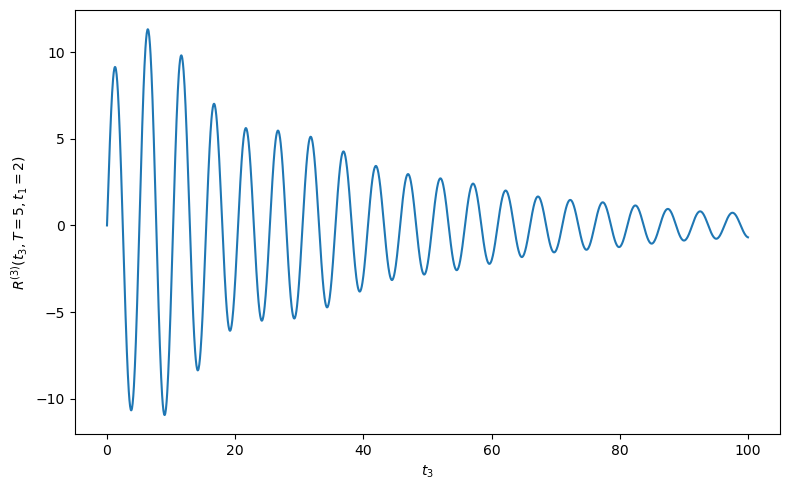

In [105]:
plt.figure(figsize=(8, 5))

plt.plot(
    t3_grid,
    np.real(R3_t3)
)

plt.xlabel(r"$t_3$")
plt.ylabel(
    r"$R^{(3)}(t_3,T=5,t_1=2)$"
)

plt.tight_layout()
plt.show()

## 3. Frequency-domain validation along the detection interval

For fixed $t_1$ and $T$, Fourier transformation over the detection
interval gives

$$
M^{(3)}(\omega_3;T,t_1)
=
\int_0^\infty
dt_3\,
e^{i\omega_3t_3}
R^{(3)}(t_3,T,t_1).
$$

Using the causal Liouvillian resolvent,

$$
G_\eta(\omega)
=
\left[
(\eta-i\omega)I-\mathcal{L}
\right]^{-1},
$$

the same quantity can be evaluated directly as

$$
\boxed{
M_{\mathrm{FD}}^{(3)}(\omega_3;T,t_1)
=
\langle\!\langle\mu|
G_\eta(\omega_3)
V
e^{\mathcal{L}T}
V
e^{\mathcal{L}t_1}
V
|\rho_0\rangle\rangle.
}
$$

To compare the two calculations consistently, the time-domain transform
uses the same exponential convergence factor,

$$
M_{\mathrm{TD}}^{(3)}(\omega_3;T,t_1)
=
\int_0^\infty
dt_3\,
e^{(i\omega_3-\eta)t_3}
R^{(3)}(t_3,T,t_1).
$$

In [106]:
# Longer detection-time grid for the Fourier transform
dt_t3 = 0.02
t3_max_ft = 250.0

t3_grid_ft = np.arange(
    0.0,
    t3_max_ft + dt_t3,
    dt_t3
)

rho3_t_ft = expm_multiply(
    L_super,
    rho3_initial,
    start=0.0,
    stop=t3_max_ft,
    num=len(t3_grid_ft),
    endpoint=True,
)

R3_t3_ft = (
    rho3_t_ft @ mu_bra
)

print(
    "Maximum |R^(3)| near final time =",
    np.max(np.abs(R3_t3_ft[-100:]))
)

Maximum |R^(3)| near final time = 0.009067624765907402


In [107]:
eta = 0.02

omega3_grid = np.linspace(
    0.6,
    1.4,
    801
)

In [108]:
M3_t3_td = []

for omega3 in omega3_grid:

    integrand = (
        np.exp(
            (1j * omega3 - eta)
            * t3_grid_ft
        )
        * R3_t3_ft
    )

    M3_t3_td.append(
        np.trapezoid(
            integrand,
            t3_grid_ft
        )
    )

M3_t3_td = np.array(
    M3_t3_td
)

In [109]:
M3_t3_fd = []

for omega3 in omega3_grid:

    A = (
        (eta - 1j * omega3) * I16
        - L_super
    )

    x = np.linalg.solve(
        A,
        rho3_initial
    )

    M3_t3_fd.append(
        mu_bra @ x
    )

M3_t3_fd = np.array(
    M3_t3_fd
)

In [110]:
t3_slice_error = (
    norm(
        M3_t3_td
        - M3_t3_fd
    )
    /
    norm(M3_t3_fd)
)

print(
    "t3-slice TD vs resolvent relative L2 error =",
    t3_slice_error
)

t3-slice TD vs resolvent relative L2 error = 8.565936401414288e-06


In [111]:
omega_a = model["omega_a"]
omega_b = model["omega_b"]
J = model["J"]

omega_minus = (
    0.5 * (omega_a + omega_b)
    - np.sqrt(
        (0.5 * (omega_a - omega_b))**2
        + J**2
    )
)

omega_plus = (
    0.5 * (omega_a + omega_b)
    + np.sqrt(
        (0.5 * (omega_a - omega_b))**2
        + J**2
    )
)

print("Omega_- =", omega_minus)
print("Omega_+ =", omega_plus)

Omega_- = 0.9585786437626906
Omega_+ = 1.2414213562373095


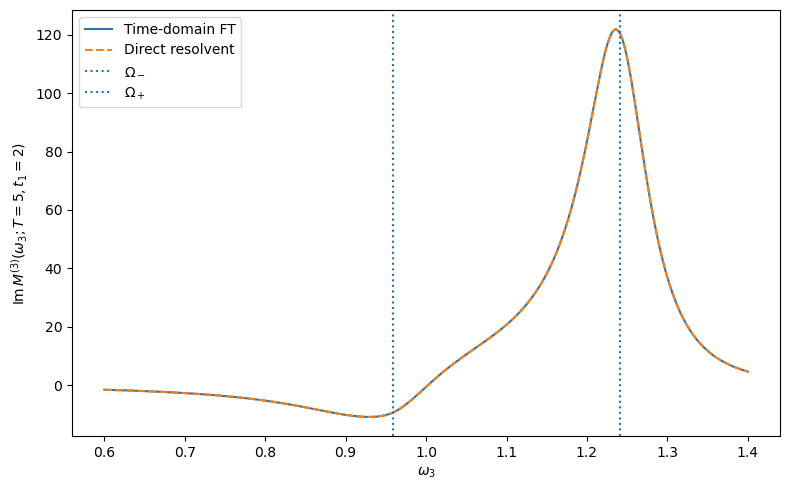

In [112]:
plt.figure(figsize=(8, 5))

plt.plot(
    omega3_grid,
    np.imag(M3_t3_td),
    label="Time-domain FT"
)

plt.plot(
    omega3_grid,
    np.imag(M3_t3_fd),
    "--",
    label="Direct resolvent"
)

plt.axvline(
    omega_minus,
    linestyle=":",
    label=r"$\Omega_-$"
)

plt.axvline(
    omega_plus,
    linestyle=":",
    label=r"$\Omega_+$"
)

plt.xlabel(r"$\omega_3$")
plt.ylabel(
    r"$\mathrm{Im}\,M^{(3)}(\omega_3;T=5,t_1=2)$"
)

plt.legend()
plt.tight_layout()
plt.show()

## 4. Frequency-domain validation along the first coherence interval

The Fourier transform over the detection interval $t_3$ has now been
validated independently.

We next fix $\omega_3$ and $T$ and retain the first coherence interval
$t_1$ explicitly.  After transforming the $t_3$ interval, define

$$
Q^{(3)}(t_1;\omega_3,T)
=
\langle\!\langle\mu|
G_\eta(\omega_3)
V
e^{\mathcal{L}T}
V
e^{\mathcal{L}t_1}
V
|\rho_0\rangle\rangle.
$$

Fourier transformation over $t_1$ gives

$$
M_{\mathrm{TD}}^{(3)}
(\omega_3,T,\omega_1)
=
\int_0^\infty
dt_1\,
e^{(i\omega_1-\eta)t_1}
Q^{(3)}(t_1;\omega_3,T).
$$

The direct frequency-domain expression is

$$
\boxed{
M_{\mathrm{FD}}^{(3)}
(\omega_3,T,\omega_1)
=
\langle\!\langle\mu|
G_\eta(\omega_3)
V
e^{\mathcal{L}T}
V
G_\eta(\omega_1)
V
|\rho_0\rangle\rangle.
}
$$

Agreement between these two calculations validates the second
Liouvillian resolvent in the third-order response.

In [113]:
# Fixed detection frequency and waiting time
omega3_fixed = omega_plus
T_fixed = 5.0

# Time grid for t1
dt_t1 = 0.02
t1_max_ft = 250.0

t1_grid_ft = np.arange(
    0.0,
    t1_max_ft + dt_t1,
    dt_t1
)

# ------------------------------------------------------------
# First interaction followed by propagation during t1
# ------------------------------------------------------------

rho_after_1 = (
    V @ rho0_vec
)

rho1_t1 = expm_multiply(
    L_super,
    rho_after_1,
    start=0.0,
    stop=t1_max_ft,
    num=len(t1_grid_ft),
    endpoint=True,
)

print(
    "rho1_t1 shape =",
    rho1_t1.shape
)

rho1_t1 shape = (12501, 16)


In [114]:
# Waiting-time propagator
prop_T = expm(
    L_super * T_fixed
)

# Second interaction
rho_after_2_t1 = (
    V @ rho1_t1.T
).T

# Waiting-time evolution
rho_after_T_t1 = (
    prop_T @ rho_after_2_t1.T
).T

# Third interaction
rho_after_3_t1 = (
    V @ rho_after_T_t1.T
).T

In [115]:
A3 = (
    (eta - 1j * omega3_fixed) * I16
    - L_super
)

In [116]:
rho_after_G3_t1 = np.linalg.solve(
    A3,
    rho_after_3_t1.T
).T

In [117]:
Q3_t1 = (
    rho_after_G3_t1
    @ mu_bra
)

print(
    "Maximum |Q^(3)| =",
    np.max(np.abs(Q3_t1))
)

print(
    "Maximum |Q^(3)| near final time =",
    np.max(np.abs(Q3_t1[-100:]))
)

Maximum |Q^(3)| = 201.4023865798169
Maximum |Q^(3)| near final time = 0.15640046193176937


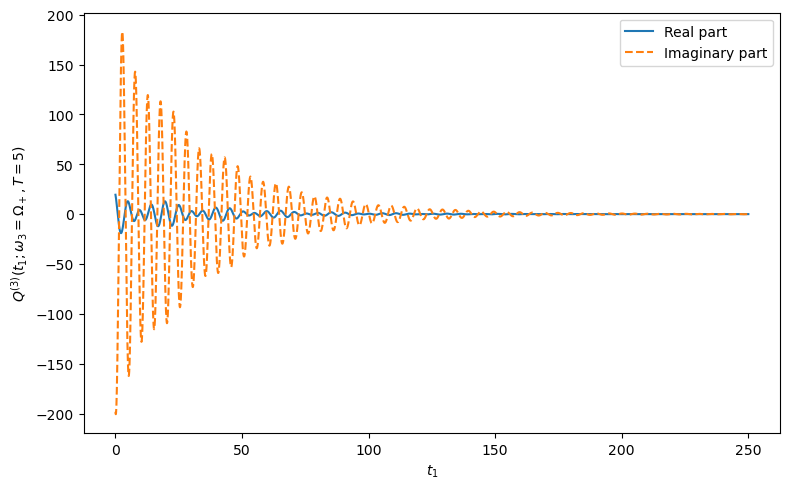

In [118]:
plt.figure(figsize=(8, 5))

plt.plot(
    t1_grid_ft,
    np.real(Q3_t1),
    label="Real part"
)

plt.plot(
    t1_grid_ft,
    np.imag(Q3_t1),
    "--",
    label="Imaginary part"
)

plt.xlabel(r"$t_1$")
plt.ylabel(
    r"$Q^{(3)}(t_1;\omega_3=\Omega_+,T=5)$"
)

plt.legend()
plt.tight_layout()
plt.show()

In [119]:
omega1_grid = np.linspace(
    0.6,
    1.4,
    801
)

In [120]:
M3_t1_td = []

for omega1 in omega1_grid:

    integrand = (
        np.exp(
            (1j * omega1 - eta)
            * t1_grid_ft
        )
        * Q3_t1
    )

    M3_t1_td.append(
        np.trapezoid(
            integrand,
            t1_grid_ft
        )
    )

M3_t1_td = np.array(
    M3_t1_td
)

In [121]:
M3_t1_fd = []

source1 = (
    V @ rho0_vec
)

for omega1 in omega1_grid:

    # First resolvent
    A1 = (
        (eta - 1j * omega1) * I16
        - L_super
    )

    x1 = np.linalg.solve(
        A1,
        source1
    )

    # Second interaction
    x2 = (
        V @ x1
    )

    # Waiting-time evolution
    xT = (
        prop_T @ x2
    )

    # Third interaction
    x3 = (
        V @ xT
    )

    # Detection resolvent
    x3_frequency = np.linalg.solve(
        A3,
        x3
    )

    M3_t1_fd.append(
        mu_bra
        @ x3_frequency
    )

M3_t1_fd = np.array(
    M3_t1_fd
)

t1_slice_error = (
    norm(
        M3_t1_td
        - M3_t1_fd
    )
    /
    norm(M3_t1_fd)
)

print(
    "t1-slice TD vs full resolvent relative L2 error =",
    t1_slice_error
)

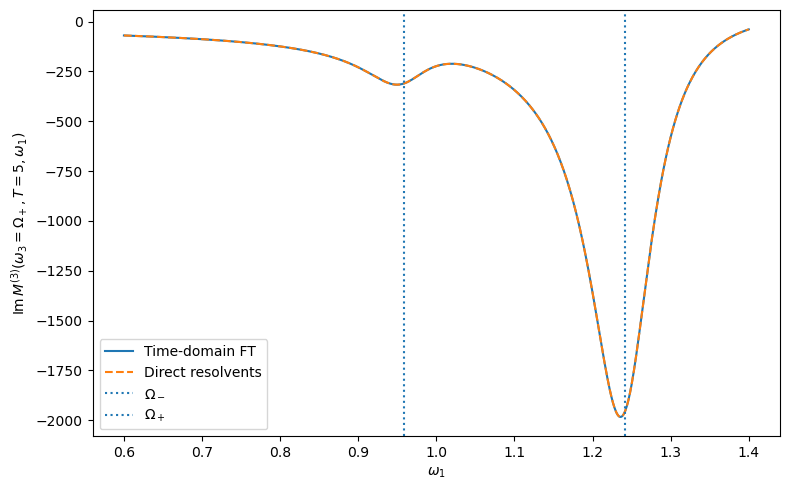

In [122]:
plt.figure(figsize=(8, 5))

plt.plot(
    omega1_grid,
    np.imag(M3_t1_td),
    label="Time-domain FT"
)

plt.plot(
    omega1_grid,
    np.imag(M3_t1_fd),
    "--",
    label="Direct resolvents"
)

plt.axvline(
    omega_minus,
    linestyle=":",
    label=r"$\Omega_-$"
)

plt.axvline(
    omega_plus,
    linestyle=":",
    label=r"$\Omega_+$"
)

plt.xlabel(r"$\omega_1$")

plt.ylabel(
    r"$\mathrm{Im}\,M^{(3)}"
    r"(\omega_3=\Omega_+,T=5,\omega_1)$"
)

plt.legend()
plt.tight_layout()
plt.show()

## 5. Direct two-dimensional third-order spectrum

Having independently validated the transformations

$$
t_3
\longrightarrow
G_\eta(\omega_3)
$$

and

$$
t_1
\longrightarrow
G_\eta(\omega_1),
$$

we now evaluate the complete mixed frequency-domain response

$$
\boxed{
M^{(3)}(\omega_3,T,\omega_1)
=
\langle\!\langle\mu|
G_\eta(\omega_3)
V
e^{\mathcal{L}T}
V
G_\eta(\omega_1)
V
|\rho_0\rangle\rangle.
}
$$

The waiting time is fixed at

$$
T=5.
$$

At this stage the full dipole-commutator superoperator $V$ is retained.
The resulting spectrum is therefore the total third-order molecular
response under the present Fourier convention.  It has not yet been
decomposed into rephasing and nonrephasing pathways.

In [123]:
# ------------------------------------------------------------
# Two-dimensional frequency grid
# ------------------------------------------------------------

T_2d = 5.0
eta_2d = 0.02

n_omega_2d = 201

omega1_2d = np.linspace(
    0.6,
    1.4,
    n_omega_2d
)

omega3_2d = np.linspace(
    0.6,
    1.4,
    n_omega_2d
)

prop_T_2d = expm(
    L_super * T_2d
)

print(
    "2D grid shape =",
    (len(omega3_2d), len(omega1_2d))
)

2D grid shape = (201, 201)


In [124]:
# ------------------------------------------------------------
# First interaction
# ------------------------------------------------------------

source1 = (
    V @ rho0_vec
)

# Will contain the state just after the third interaction
# for every omega_1.
#
# Shape:
#     16 x N_omega1
#
source_for_G3 = np.zeros(
    (16, len(omega1_2d)),
    dtype=complex
)

for i, omega1 in enumerate(omega1_2d):

    A1 = (
        (eta_2d - 1j * omega1) * I16
        - L_super
    )

    # First coherence interval in frequency space
    x1 = np.linalg.solve(
        A1,
        source1
    )

    # Second interaction
    x2 = (
        V @ x1
    )

    # Waiting-time evolution
    xT = (
        prop_T_2d @ x2
    )

    # Third interaction
    x3 = (
        V @ xT
    )

    source_for_G3[:, i] = x3

print(
    "source_for_G3 shape =",
    source_for_G3.shape
)

source_for_G3 shape = (16, 201)


In [125]:
# ------------------------------------------------------------
# Complete 2D direct-resolvent response
# ------------------------------------------------------------

M3_2d = np.zeros(
    (
        len(omega3_2d),
        len(omega1_2d)
    ),
    dtype=complex
)

for j, omega3 in enumerate(omega3_2d):

    A3 = (
        (eta_2d - 1j * omega3) * I16
        - L_super
    )

    # Solve for every omega_1 simultaneously
    X3 = np.linalg.solve(
        A3,
        source_for_G3
    )

    M3_2d[j, :] = (
        mu_bra @ X3
    )

print(
    "M3_2d shape =",
    M3_2d.shape
)

print(
    "All values finite =",
    np.all(np.isfinite(M3_2d))
)

print(
    "Maximum |M^(3)| =",
    np.max(np.abs(M3_2d))
)

M3_2d shape = (201, 201)
All values finite = True
Maximum |M^(3)| = 2035.36239754598


In [126]:
max_index = np.unravel_index(
    np.argmax(np.abs(M3_2d)),
    M3_2d.shape
)

j_max, i_max = max_index

print(
    "Largest |M^(3)| at:"
)

print(
    "omega_1 =",
    omega1_2d[i_max]
)

print(
    "omega_3 =",
    omega3_2d[j_max]
)

print(
    "M^(3) =",
    M3_2d[j_max, i_max]
)

Largest |M^(3)| at:
omega_1 = 1.244
omega_3 = 1.236
M^(3) = (410.97226172077575-1993.4397130187385j)


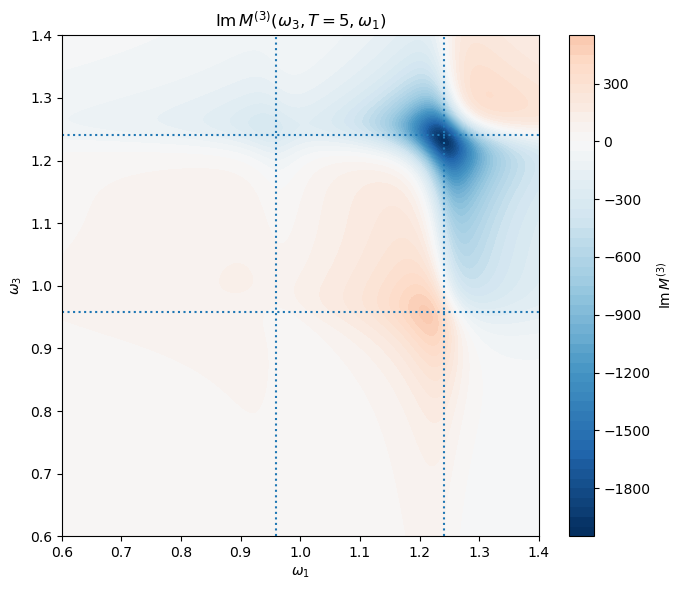

In [127]:
imag_max = np.max(
    np.abs(np.imag(M3_2d))
)

plt.figure(figsize=(7, 6))

plt.contourf(
    omega1_2d,
    omega3_2d,
    np.imag(M3_2d),
    levels=60,
    vmin=-imag_max,
    vmax=imag_max,
    cmap="RdBu_r"
)

plt.colorbar(
    label=r"$\mathrm{Im}\,M^{(3)}$"
)

plt.axvline(
    omega_minus,
    linestyle=":"
)

plt.axvline(
    omega_plus,
    linestyle=":"
)

plt.axhline(
    omega_minus,
    linestyle=":"
)

plt.axhline(
    omega_plus,
    linestyle=":"
)

plt.xlabel(r"$\omega_1$")
plt.ylabel(r"$\omega_3$")

plt.title(
    r"$\mathrm{Im}\,M^{(3)}"
    r"(\omega_3,T=5,\omega_1)$"
)

plt.tight_layout()
plt.show()

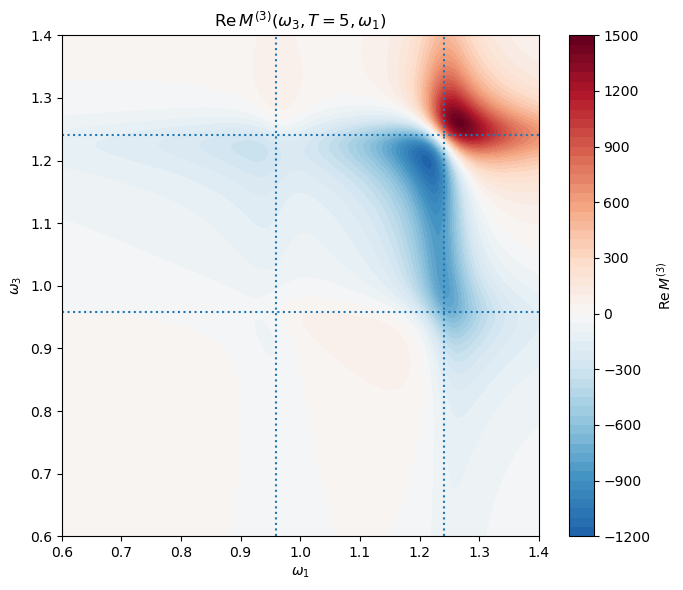

In [128]:
real_max = np.max(
    np.abs(np.real(M3_2d))
)

plt.figure(figsize=(7, 6))

plt.contourf(
    omega1_2d,
    omega3_2d,
    np.real(M3_2d),
    levels=60,
    vmin=-real_max,
    vmax=real_max,
    cmap="RdBu_r"
)

plt.colorbar(
    label=r"$\mathrm{Re}\,M^{(3)}$"
)

plt.axvline(
    omega_minus,
    linestyle=":"
)

plt.axvline(
    omega_plus,
    linestyle=":"
)

plt.axhline(
    omega_minus,
    linestyle=":"
)

plt.axhline(
    omega_plus,
    linestyle=":"
)

plt.xlabel(r"$\omega_1$")
plt.ylabel(r"$\omega_3$")

plt.title(
    r"$\mathrm{Re}\,M^{(3)}"
    r"(\omega_3,T=5,\omega_1)$"
)

plt.tight_layout()
plt.show()

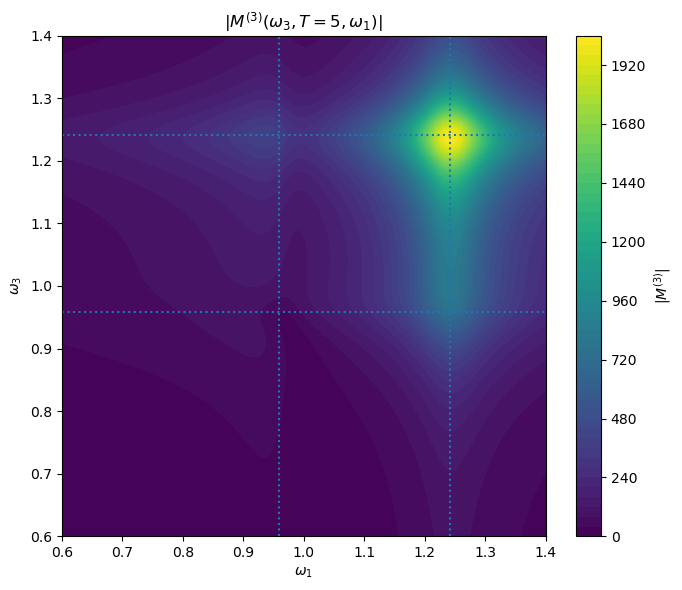

In [129]:
plt.figure(figsize=(7, 6))

plt.contourf(
    omega1_2d,
    omega3_2d,
    np.abs(M3_2d),
    levels=60
)

plt.colorbar(
    label=r"$|M^{(3)}|$"
)

plt.axvline(
    omega_minus,
    linestyle=":"
)

plt.axvline(
    omega_plus,
    linestyle=":"
)

plt.axhline(
    omega_minus,
    linestyle=":"
)

plt.axhline(
    omega_plus,
    linestyle=":"
)

plt.xlabel(r"$\omega_1$")
plt.ylabel(r"$\omega_3$")

plt.title(
    r"$|M^{(3)}"
    r"(\omega_3,T=5,\omega_1)|$"
)

plt.tight_layout()
plt.show()

## 6. Full two-dimensional time-domain validation

The previous calculations validated the $t_3$ and $t_1$ Fourier
transformations separately.  We now perform a complete two-dimensional
time-domain calculation and compare it directly with the mixed
frequency-domain resolvent expression.

At fixed waiting time $T$,

$$
R^{(3)}(t_3,T,t_1)
=
\langle\!\langle\mu|
e^{\mathcal{L}t_3}
V
e^{\mathcal{L}T}
V
e^{\mathcal{L}t_1}
V
|\rho_0\rangle\rangle.
$$

It is convenient to write

$$
B(t_3)
=
\langle\!\langle\mu|
e^{\mathcal{L}t_3},
$$

and

$$
A(t_1)
=
V
e^{\mathcal{L}T}
V
e^{\mathcal{L}t_1}
V
|\rho_0\rangle\rangle.
$$

Then

$$
R^{(3)}(t_3,T,t_1)
=
B(t_3)A(t_1).
$$

The complete damped double Fourier transform is

$$
M_{\mathrm{TD}}^{(3)}
(\omega_3,T,\omega_1)
=
\int_0^\infty dt_3
\int_0^\infty dt_1\,
e^{(i\omega_3-\eta)t_3}
e^{(i\omega_1-\eta)t_1}
R^{(3)}(t_3,T,t_1).
$$

This will be compared with

$$
\boxed{
M_{\mathrm{FD}}^{(3)}
(\omega_3,T,\omega_1)
=
\langle\!\langle\mu|
G_\eta(\omega_3)
V
e^{\mathcal{L}T}
V
G_\eta(\omega_1)
V
|\rho_0\rangle\rangle.
}
$$

The same value of $\eta$ is used in the time-domain transform and in
both resolvents.

In [130]:
# ------------------------------------------------------------
# Full 2D time-domain validation parameters
# ------------------------------------------------------------

T_2d_td = 5.0
eta_2d_td = 0.02

dt_2d_td = 0.05
t_max_2d_td = 250.0

t1_2d_td = np.arange(
    0.0,
    t_max_2d_td + dt_2d_td,
    dt_2d_td
)

t3_2d_td = np.arange(
    0.0,
    t_max_2d_td + dt_2d_td,
    dt_2d_td
)

omega1_test = np.linspace(
    0.6,
    1.4,
    41
)

omega3_test = np.linspace(
    0.6,
    1.4,
    41
)

print("Nt1 =", len(t1_2d_td))
print("Nt3 =", len(t3_2d_td))
print(
    "Frequency grid =",
    (len(omega3_test), len(omega1_test))
)

Nt1 = 5001
Nt3 = 5001
Frequency grid = (41, 41)


In [131]:
# First interaction
source1_td = (
    V @ rho0_vec
)

# Explicit propagation over t1
rho1_t1_2d = expm_multiply(
    L_super,
    source1_td,
    start=0.0,
    stop=t_max_2d_td,
    num=len(t1_2d_td),
    endpoint=True,
)

print(
    "rho1_t1_2d shape =",
    rho1_t1_2d.shape
)

rho1_t1_2d shape = (5001, 16)


In [132]:
prop_T_td = expm(
    L_super * T_2d_td
)

# Second interaction
rho2_t1_2d = (
    V @ rho1_t1_2d.T
).T

# Waiting-time evolution
rhoT_t1_2d = (
    prop_T_td @ rho2_t1_2d.T
).T

# Third interaction
A_t1 = (
    V @ rhoT_t1_2d.T
).T

print(
    "A(t1) shape =",
    A_t1.shape
)

A(t1) shape = (5001, 16)


In [133]:
B_t3 = expm_multiply(
    L_super.T,
    mu_bra,
    start=0.0,
    stop=t_max_2d_td,
    num=len(t3_2d_td),
    endpoint=True,
)

print(
    "B(t3) shape =",
    B_t3.shape
)

B(t3) shape = (5001, 16)


In [134]:
trap1 = np.ones(
    len(t1_2d_td)
)

trap1[0] = 0.5
trap1[-1] = 0.5

trap1 *= dt_2d_td


trap3 = np.ones(
    len(t3_2d_td)
)

trap3[0] = 0.5
trap3[-1] = 0.5

trap3 *= dt_2d_td

In [135]:
W1 = (
    trap1[None, :]
    * np.exp(
        (
            1j * omega1_test[:, None]
            - eta_2d_td
        )
        * t1_2d_td[None, :]
    )
)

In [136]:
W3 = (
    trap3[None, :]
    * np.exp(
        (
            1j * omega3_test[:, None]
            - eta_2d_td
        )
        * t3_2d_td[None, :]
    )
)

In [137]:
print("W1 shape =", W1.shape)
print("W3 shape =", W3.shape)

W1 shape = (41, 5001)
W3 shape = (41, 5001)


In [138]:
B_omega3_td = (
    W3 @ B_t3
)

In [139]:
A_omega1_td = (
    W1 @ A_t1
)

In [140]:
M3_2d_td = (
    B_omega3_td
    @ A_omega1_td.T
)

print(
    "M3_2d_td shape =",
    M3_2d_td.shape
)

M3_2d_td shape = (41, 41)


In [141]:
# ------------------------------------------------------------
# Direct frequency-domain calculation on the same grid
# ------------------------------------------------------------

source_for_G3_test = np.zeros(
    (16, len(omega1_test)),
    dtype=complex
)

for i, omega1 in enumerate(omega1_test):

    A1 = (
        (eta_2d_td - 1j * omega1) * I16
        - L_super
    )

    x1 = np.linalg.solve(
        A1,
        source1_td
    )

    x2 = (
        V @ x1
    )

    xT = (
        prop_T_td @ x2
    )

    x3 = (
        V @ xT
    )

    source_for_G3_test[:, i] = x3

In [142]:
M3_2d_fd_test = np.zeros(
    (
        len(omega3_test),
        len(omega1_test)
    ),
    dtype=complex
)

for j, omega3 in enumerate(omega3_test):

    A3 = (
        (eta_2d_td - 1j * omega3) * I16
        - L_super
    )

    X3 = np.linalg.solve(
        A3,
        source_for_G3_test
    )

    M3_2d_fd_test[j, :] = (
        mu_bra @ X3
    )

In [143]:
full_2d_relative_error = (
    norm(
        M3_2d_td
        - M3_2d_fd_test
    )
    /
    norm(M3_2d_fd_test)
)

print(
    "Full 2D TD vs resolvent relative L2 error =",
    full_2d_relative_error
)

Full 2D TD vs resolvent relative L2 error = 5.403065591438443e-05


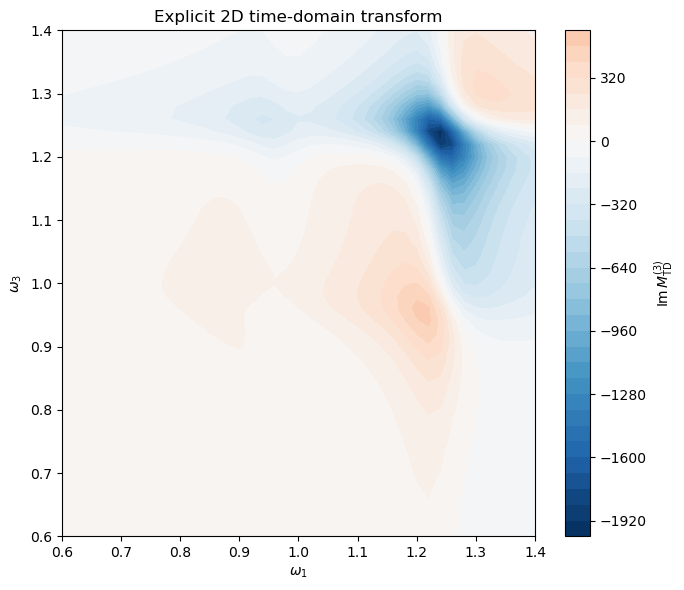

In [144]:
imag_limit = max(
    np.max(
        np.abs(
            np.imag(M3_2d_td)
        )
    ),
    np.max(
        np.abs(
            np.imag(M3_2d_fd_test)
        )
    )
)

plt.figure(figsize=(7, 6))

plt.contourf(
    omega1_test,
    omega3_test,
    np.imag(M3_2d_td),
    levels=40,
    vmin=-imag_limit,
    vmax=imag_limit,
    cmap="RdBu_r"
)

plt.colorbar(
    label=r"$\mathrm{Im}\,M_{\mathrm{TD}}^{(3)}$"
)

plt.xlabel(r"$\omega_1$")
plt.ylabel(r"$\omega_3$")

plt.title(
    "Explicit 2D time-domain transform"
)

plt.tight_layout()
plt.savefig(
    figures_dir / "third_order_impulsive_td.pdf",
    bbox_inches="tight"
)
plt.show()

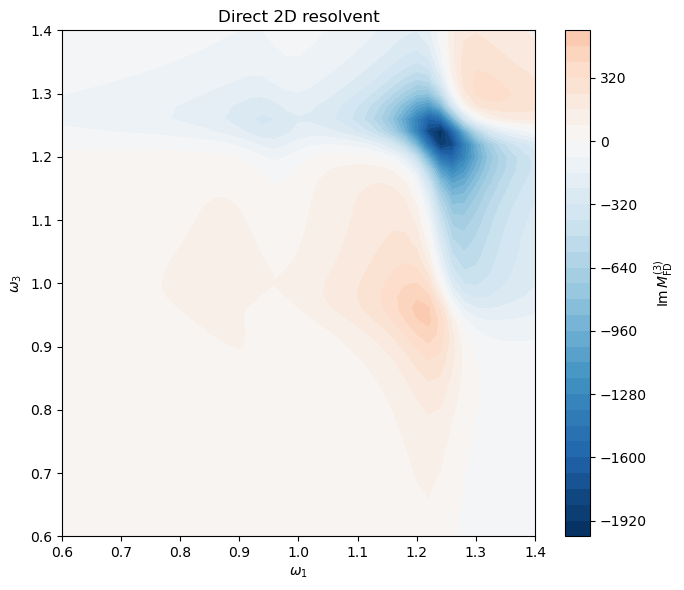

In [145]:
plt.figure(figsize=(7, 6))

plt.contourf(
    omega1_test,
    omega3_test,
    np.imag(M3_2d_fd_test),
    levels=40,
    vmin=-imag_limit,
    vmax=imag_limit,
    cmap="RdBu_r"
)

plt.colorbar(
    label=r"$\mathrm{Im}\,M_{\mathrm{FD}}^{(3)}$"
)

plt.xlabel(r"$\omega_1$")
plt.ylabel(r"$\omega_3$")

plt.title(
    "Direct 2D resolvent"
)

plt.tight_layout()
figures_dir = repo_root / "figures"
figures_dir.mkdir(exist_ok=True)

plt.savefig(
    figures_dir / "third_order_direct_2d_resolvent.pdf",
    bbox_inches="tight"
)
plt.show()

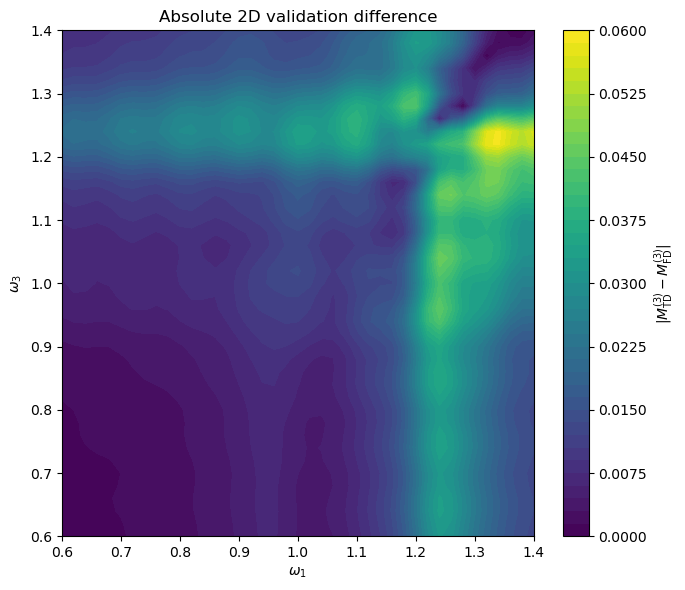

In [146]:
difference_2d = (
    M3_2d_td
    - M3_2d_fd_test
)

plt.figure(figsize=(7, 6))

plt.contourf(
    omega1_test,
    omega3_test,
    np.abs(difference_2d),
    levels=40
)

plt.colorbar(
    label=r"$|M_{\mathrm{TD}}^{(3)}-M_{\mathrm{FD}}^{(3)}|$"
)

plt.xlabel(r"$\omega_1$")
plt.ylabel(r"$\omega_3$")

plt.title(
    "Absolute 2D validation difference"
)

plt.tight_layout()
plt.savefig(
    figures_dir / "third_order_2d_validation_difference.pdf",
    bbox_inches="tight"
)
plt.show()

## 7. Validation of the direct third-order resolvent

The third-order response was validated progressively from the time
domain to the complete mixed frequency-domain representation.

For fixed $t_1$ and $T$, explicit propagation over the detection
interval followed by Fourier transformation agreed with the direct
$\omega_3$ resolvent calculation with relative error

$$
\epsilon_{t_3}
=
8.57\times10^{-6}.
$$

After transforming the detection interval, explicit propagation and
Fourier transformation over the first coherence interval agreed with
the complete two-resolvent expression with relative error

$$
\epsilon_{t_1}
=
9.21\times10^{-6}.
$$

Finally, the complete two-dimensional time-domain response,

$$
R^{(3)}(t_3,T,t_1)
=
\langle\!\langle\mu|
e^{\mathcal{L}t_3}
V
e^{\mathcal{L}T}
V
e^{\mathcal{L}t_1}
V
|\rho_0\rangle\rangle,
$$

was propagated explicitly and transformed over both $t_1$ and $t_3$.

The resulting two-dimensional spectrum agrees with the direct
frequency-domain expression

$$
\boxed{
M^{(3)}(\omega_3,T,\omega_1)
=
\langle\!\langle\mu|
G_\eta(\omega_3)
V
e^{\mathcal{L}T}
V
G_\eta(\omega_1)
V
|\rho_0\rangle\rangle
}
$$

with relative complex $L^2$ error

$$
\boxed{
\epsilon_{\mathrm{2D}}
=
5.40\times10^{-5}.
}
$$

The explicit time-domain and direct resolvent spectra are visually
indistinguishable on the scale of the molecular response.

This establishes the numerical equivalence

$$
\boxed{
\text{explicit two-dimensional time-domain spectroscopy}
\longleftrightarrow
\text{direct two-dimensional Liouvillian-resolvent spectroscopy}.
}
$$

The remaining numerical difference is consistent with finite-time
truncation and quadrature error.

At this stage the full dipole-commutator interaction superoperator $V$
has been retained.  The spectrum is therefore the total third-order
molecular response and has not yet been decomposed into rephasing and
nonrephasing contributions.

## 8. RWA-resolved light--matter interaction

The third-order response has so far been calculated using the complete
dipole-commutator superoperator

$$
V
=
\frac{i}{\hbar}
[\mu,\cdot].
$$

This is sufficient for validating the total molecular response, but a
conventional rephasing/nonrephasing decomposition requires resolving the
light--matter interaction into excitation-raising and
excitation-lowering components.

For the present dimer, the dipole operator connects neighboring
excitation manifolds,

$$
\mu
=
\mu_{\uparrow}
+
\mu_{\downarrow},
$$

where $\mu_{\uparrow}$ raises the excitation number by one and

$$
\mu_{\downarrow}
=
\mu_{\uparrow}^{\dagger}.
$$

We define the corresponding interaction superoperators

$$
V_{\uparrow}
=
\frac{i}{\hbar}
[\mu_{\uparrow},\cdot],
$$

and

$$
V_{\downarrow}
=
\frac{i}{\hbar}
[\mu_{\downarrow},\cdot].
$$

Therefore,

$$
\boxed{
V
=
V_{\uparrow}
+
V_{\downarrow}.
}
$$

With the field convention

$$
E^{(+)}(t)
\propto
e^{-i\omega_L t},
$$

the rotating-wave approximation pairs

$$
\boxed{
E^{(+)}
\longleftrightarrow
\mu_{\uparrow},
\qquad
E^{(-)}
\longleftrightarrow
\mu_{\downarrow}.
}
$$

Thus, a field-sign sequence $(s_1,s_2,s_3)$ determines which
interaction superoperator acts at each light--matter interaction.

In particular, the positive phase-matched rephasing and nonrephasing
signatures are

$$
A_R:
(-,+,+),
$$

and

$$
A_{NR}:
(+,-,+).
$$

Their RWA interaction sequences are therefore

$$
A_R:
\qquad
V_{\downarrow}
\rightarrow
V_{\uparrow}
\rightarrow
V_{\uparrow},
$$

and

$$
A_{NR}:
\qquad
V_{\uparrow}
\rightarrow
V_{\downarrow}
\rightarrow
V_{\uparrow}.
$$

The pathway-resolved calculations below will be compared only after the
identity $V=V_{\uparrow}+V_{\downarrow}$ has been verified numerically.

In [147]:
# ------------------------------------------------------------
# Raising and lowering parts of the dipole
# ------------------------------------------------------------

excitation_number = np.array([
    0,  # |gg>
    1,  # |eg>
    1,  # |ge>
    2,  # |ee>
])

mu_up = np.zeros_like(
    mu,
    dtype=complex
)

for i in range(d):
    for j in range(d):

        # Matrix element |i><j| raises the excitation
        # number when n_i = n_j + 1.
        if (
            excitation_number[i]
            == excitation_number[j] + 1
        ):
            mu_up[i, j] = mu[i, j]

mu_down = (
    mu_up.conj().T
)

print("mu_up =")
print(mu_up)

print()
print("mu_down =")
print(mu_down)

mu_up =
[[0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 1.+0.j 0.+0.j]]

mu_down =
[[0.-0.j 1.-0.j 1.-0.j 0.-0.j]
 [0.-0.j 0.-0.j 0.-0.j 1.-0.j]
 [0.-0.j 0.-0.j 0.-0.j 1.-0.j]
 [0.-0.j 0.-0.j 0.-0.j 0.-0.j]]


In [148]:
dipole_split_error = norm(
    mu
    - (
        mu_up
        + mu_down
    )
)

print(
    "Dipole decomposition error =",
    dipole_split_error
)

print(
    "Adjoint relation error =",
    norm(
        mu_down
        - mu_up.conj().T
    )
)

Dipole decomposition error = 0.0
Adjoint relation error = 0.0


In [149]:
def commutator_super(A):
    return (
        1j / hbar
        * (
            np.kron(
                np.eye(d),
                A
            )
            -
            np.kron(
                A.T,
                np.eye(d)
            )
        )
    )


V_up = commutator_super(
    mu_up
)

V_down = commutator_super(
    mu_down
)

In [150]:
V_split_error = (
    norm(
        V
        - (
            V_up
            + V_down
        )
    )
    /
    norm(V)
)

print(
    "Relative V decomposition error =",
    V_split_error
)

Relative V decomposition error = 0.0


In [151]:
rho_first_up = (
    V_up @ rho0_vec
)

rho_first_down = (
    V_down @ rho0_vec
)

print(
    "First interaction with V_up:"
)
print(
    np.round(
        unvec(rho_first_up, d),
        6
    )
)

print()

print(
    "First interaction with V_down:"
)
print(
    np.round(
        unvec(rho_first_down, d),
        6
    )
)

First interaction with V_up:
[[0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+1.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+1.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]]

First interaction with V_down:
[[0.+0.j 0.-1.j 0.-1.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]]


## 9. Coherence-frequency sign convention

The RWA-resolved first interactions generate conjugate optical
coherences.

For the prepared ground state,

$$
V_{\uparrow}|\rho_0\rangle\rangle
$$

creates ket-side coherences of the form

$$
|e\rangle\langle g|,
$$

which evolve approximately as

$$
e^{-i\Omega t_1}.
$$

In contrast,

$$
V_{\downarrow}|\rho_0\rangle\rangle
$$

creates bra-side coherences

$$
|g\rangle\langle e|,
$$

which evolve approximately as

$$
e^{+i\Omega t_1}.
$$

Under the Fourier convention

$$
f(\omega)
=
\int_0^\infty
dt\,
e^{+i\omega t}
f(t),
$$

the ket-side coherence is resonant at positive frequency,

$$
\omega=+\Omega,
$$

whereas the bra-side coherence is resonant at negative frequency,

$$
\omega=-\Omega.
$$

Therefore the conventional positive excitation-frequency axis is
represented differently for the two phase-matched signals:

$$
\boxed{
\text{nonrephasing: }
G(+\omega_1)
}
$$

and

$$
\boxed{
\text{rephasing: }
G(-\omega_1).
}
$$

Equivalently, the rephasing response may be calculated on a negative
$\omega_1$ axis and displayed against $-\omega_1$.

In [152]:
# ------------------------------------------------------------
# Frequency sign of the two first-coherence branches
# ------------------------------------------------------------

omega_sign_grid = np.linspace(
    -1.4,
    1.4,
    1401
)

eta_sign = 0.02

source_up = (
    V_up @ rho0_vec
)

source_down = (
    V_down @ rho0_vec
)

C_up = []
C_down = []

for omega in omega_sign_grid:

    A = (
        (eta_sign - 1j * omega) * I16
        - L_super
    )

    x_up = np.linalg.solve(
        A,
        source_up
    )

    x_down = np.linalg.solve(
        A,
        source_down
    )

    C_up.append(
        mu_bra @ x_up
    )

    C_down.append(
        mu_bra @ x_down
    )

C_up = np.array(C_up)
C_down = np.array(C_down)

In [153]:
i_up_max = np.argmax(
    np.abs(C_up)
)

i_down_max = np.argmax(
    np.abs(C_down)
)

print(
    "V_up branch maximum at omega =",
    omega_sign_grid[i_up_max]
)

print(
    "V_down branch maximum at omega =",
    omega_sign_grid[i_down_max]
)

V_up branch maximum at omega = 1.242
V_down branch maximum at omega = -1.242


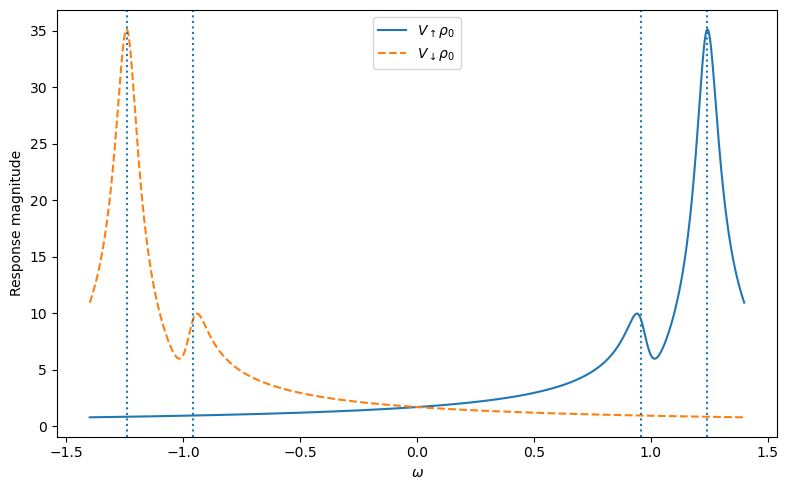

In [154]:
plt.figure(figsize=(8, 5))

plt.plot(
    omega_sign_grid,
    np.abs(C_up),
    label=r"$V_{\uparrow}\rho_0$"
)

plt.plot(
    omega_sign_grid,
    np.abs(C_down),
    "--",
    label=r"$V_{\downarrow}\rho_0$"
)

plt.axvline(
    omega_minus,
    linestyle=":"
)

plt.axvline(
    omega_plus,
    linestyle=":"
)

plt.axvline(
    -omega_minus,
    linestyle=":"
)

plt.axvline(
    -omega_plus,
    linestyle=":"
)

plt.xlabel(r"$\omega$")
plt.ylabel("Response magnitude")

plt.legend()
plt.tight_layout()
plt.show()

## 10. Positive-frequency polarization detection

The total third-order polarization is obtained from the expectation
value of the full dipole operator,

$$
P^{(3)}(t)
=
\operatorname{Tr}
\left[
\mu\,\rho^{(3)}(t)
\right],
$$

with

$$
\mu
=
\mu_{\uparrow}
+
\mu_{\downarrow},
\qquad
\mu_{\downarrow}
=
\mu_{\uparrow}^{\dagger}.
$$

The two parts of the polarization can be separated according to their
optical time dependence.

A ket-side optical coherence,

$$
|e\rangle\langle g|,
$$

evolves approximately as

$$
|e\rangle\langle g|
\longrightarrow
e^{-i\Omega t}
|e\rangle\langle g|.
$$

The corresponding dipole expectation value is obtained from the
lowering part of the physical dipole,

$$
P^{(+)}(t)
=
\operatorname{Tr}
\left[
\mu_{\downarrow}
\rho^{(3)}(t)
\right],
$$

and therefore has the positive-frequency time dependence

$$
P^{(+)}(t)
\propto
e^{-i\Omega t}.
$$

Similarly, a bra-side coherence,

$$
|g\rangle\langle e|,
$$

evolves approximately as

$$
e^{+i\Omega t},
$$

and contributes to

$$
P^{(-)}(t)
=
\operatorname{Tr}
\left[
\mu_{\uparrow}
\rho^{(3)}(t)
\right].
$$

### Liouville-space detection vectors

Care is required when expressing these quantities in Liouville space.
With the Hilbert--Schmidt inner product,

$$
\langle\!\langle A|\rho\rangle\rangle
=
\operatorname{vec}(A)^{\dagger}
\operatorname{vec}(\rho)
=
\operatorname{Tr}
\left[
A^{\dagger}\rho
\right].
$$

Therefore,

$$
\langle\!\langle\mu_{\uparrow}|\rho\rangle\rangle
=
\operatorname{Tr}
\left[
\mu_{\uparrow}^{\dagger}\rho
\right]
=
\operatorname{Tr}
\left[
\mu_{\downarrow}\rho
\right],
$$

whereas

$$
\langle\!\langle\mu_{\downarrow}|\rho\rangle\rangle
=
\operatorname{Tr}
\left[
\mu_{\uparrow}\rho
\right].
$$

Consequently, the positive-frequency polarization is represented in
Liouville space by

$$
\boxed{
P^{(+)}(t)
=
\langle\!\langle
\mu_{\uparrow}
|
\rho^{(3)}(t)
\rangle\rangle,
}
$$

while the conjugate negative-frequency polarization is

$$
\boxed{
P^{(-)}(t)
=
\langle\!\langle
\mu_{\downarrow}
|
\rho^{(3)}(t)
\rangle\rangle.
}
$$

This apparent reversal of the labels arises solely from the Hermitian
conjugation contained in the Hilbert--Schmidt bra.

The numerical test confirms this explicitly:

$$
\langle\!\langle
\mu_{\uparrow}
|
\,|e\rangle\langle g|
\rangle\rangle
\neq0,
\qquad
\langle\!\langle
\mu_{\downarrow}
|
\,|e\rangle\langle g|
\rangle\rangle
=0,
$$

whereas

$$
\langle\!\langle
\mu_{\downarrow}
|
\,|g\rangle\langle e|
\rangle\rangle
\neq0.
$$

### RWA-resolved rephasing and nonrephasing signals

With the field convention

$$
E^{(+)}(t)
\propto
e^{-i\omega_L t},
$$

the rotating-wave approximation pairs

$$
E^{(+)}
\longleftrightarrow
\mu_{\uparrow},
\qquad
E^{(-)}
\longleftrightarrow
\mu_{\downarrow},
$$

and therefore

$$
E^{(+)}
\longleftrightarrow
V_{\uparrow},
\qquad
E^{(-)}
\longleftrightarrow
V_{\downarrow}.
$$

For the positive phase-matched nonrephasing field signature

$$
A_{NR}:
\qquad
(+,-,+),
$$

the interaction sequence is

$$
V_{\uparrow}
\rightarrow
V_{\downarrow}
\rightarrow
V_{\uparrow}.
$$

The corresponding positive-frequency molecular response is

$$
\boxed{
M_{NR}^{(3)}
(\omega_3,T,\omega_1)
=
\langle\!\langle\mu_{\uparrow}|
G_{\eta}(\omega_3)
V_{\uparrow}
e^{\mathcal{L}T}
V_{\downarrow}
G_{\eta}(\omega_1)
V_{\uparrow}
|\rho_0\rangle\rangle.
}
$$

The first interaction produces a ket-side coherence,

$$
V_{\uparrow}|\rho_0\rangle\rangle
\sim
|e\rangle\langle g|,
$$

which evolves approximately as

$$
e^{-i\Omega t_1}
$$

and is therefore resonant at positive raw Fourier frequency,

$$
\omega_1\simeq+\Omega.
$$

For the positive phase-matched rephasing field signature

$$
A_R:
\qquad
(-,+,+),
$$

the interaction sequence is

$$
V_{\downarrow}
\rightarrow
V_{\uparrow}
\rightarrow
V_{\uparrow}.
$$

Using a raw first-coherence Fourier frequency $\nu_1$, the corresponding
positive-frequency molecular response is

$$
\boxed{
M_R^{(3)}
(\omega_3,T,\nu_1)
=
\langle\!\langle\mu_{\uparrow}|
G_{\eta}(\omega_3)
V_{\uparrow}
e^{\mathcal{L}T}
V_{\uparrow}
G_{\eta}(\nu_1)
V_{\downarrow}
|\rho_0\rangle\rangle.
}
$$

The first interaction now produces a bra-side coherence,

$$
V_{\downarrow}|\rho_0\rangle\rangle
\sim
|g\rangle\langle e|,
$$

which evolves approximately as

$$
e^{+i\Omega t_1}.
$$

Under the Fourier convention

$$
f(\nu_1)
=
\int_0^\infty
dt_1\,
e^{+i\nu_1 t_1}
f(t_1),
$$

this coherence is resonant at

$$
\nu_1\simeq-\Omega.
$$

Thus, at this stage we retain the raw Fourier-frequency convention:

$$
\boxed{
\text{nonrephasing: }
\omega_1>0,
\qquad
\text{rephasing: }
\nu_1<0.
}
$$

If a later comparison or plotting convention uses a positive
rephasing excitation-frequency axis, one may define

$$
\omega_1^{(R)}
=
-\nu_1,
$$

which is equivalent to replacing

$$
G_{\eta}(\nu_1)
\rightarrow
G_{\eta}(-\omega_1^{(R)}).
$$

No such axis transformation is applied at this stage.

In [155]:
mu_up_bra = vec(mu_up).conj()
mu_down_bra = vec(mu_down).conj()

In [156]:
# Basis vectors
gg = np.array([1, 0, 0, 0], dtype=complex)
eg = np.array([0, 1, 0, 0], dtype=complex)

ket_coherence = np.outer(eg, gg.conj())
bra_coherence = np.outer(gg, eg.conj())

ket_vec = vec(ket_coherence)
bra_vec = vec(bra_coherence)

print("Ket coherence |eg><gg|:")
print(
    "<mu_down|rho> =",
    mu_down_bra @ ket_vec
)
print(
    "<mu_up|rho>   =",
    mu_up_bra @ ket_vec
)

print()

print("Bra coherence |gg><eg|:")
print(
    "<mu_down|rho> =",
    mu_down_bra @ bra_vec
)
print(
    "<mu_up|rho>   =",
    mu_up_bra @ bra_vec
)

Ket coherence |eg><gg|:
<mu_down|rho> = 0j
<mu_up|rho>   = (1+0j)

Bra coherence |gg><eg|:
<mu_down|rho> = (1+0j)
<mu_up|rho>   = 0j


## 11. RWA-resolved rephasing and nonrephasing spectra

We now evaluate the positive-frequency rephasing and nonrephasing
third-order molecular responses using the RWA-resolved interaction
superoperators.

For the nonrephasing field signature

$$
(+,-,+),
$$

the interaction sequence is

$$
V_{\uparrow}
\rightarrow
V_{\downarrow}
\rightarrow
V_{\uparrow}.
$$

The corresponding positive-frequency response is

$$
\boxed{
M_{NR}^{(3)}
(\omega_3,T,\omega_1)
=
\langle\!\langle\mu_{\uparrow}|
G_{\eta}(\omega_3)
V_{\uparrow}
e^{\mathcal{L}T}
V_{\downarrow}
G_{\eta}(\omega_1)
V_{\uparrow}
|\rho_0\rangle\rangle.
}
$$

The first interaction creates a ket-side coherence and is therefore
resonant at positive raw Fourier frequency,

$$
\omega_1>0.
$$

For the rephasing field signature

$$
(-,+,+),
$$

the interaction sequence is

$$
V_{\downarrow}
\rightarrow
V_{\uparrow}
\rightarrow
V_{\uparrow}.
$$

Using the raw first-coherence Fourier variable $\nu_1$, the corresponding
response is

$$
\boxed{
M_R^{(3)}
(\omega_3,T,\nu_1)
=
\langle\!\langle\mu_{\uparrow}|
G_{\eta}(\omega_3)
V_{\uparrow}
e^{\mathcal{L}T}
V_{\uparrow}
G_{\eta}(\nu_1)
V_{\downarrow}
|\rho_0\rangle\rangle.
}
$$

The first interaction creates a bra-side coherence and is therefore
resonant at negative raw Fourier frequency,

$$
\nu_1<0.
$$

At this stage the raw Fourier axes are retained without transformation.

In [157]:
T_rnr = 5.0
eta_rnr = 0.02

n_rnr = 201

# Nonrephasing first-coherence axis
omega1_nr = np.linspace(
    0.6,
    1.4,
    n_rnr
)

# Rephasing raw first-coherence axis
nu1_r = np.linspace(
    -1.4,
    -0.6,
    n_rnr
)

# Detection axis
omega3_rnr = np.linspace(
    0.6,
    1.4,
    n_rnr
)

prop_T_rnr = expm(
    L_super * T_rnr
)

print(
    "NR grid =",
    (len(omega3_rnr), len(omega1_nr))
)

print(
    "R grid =",
    (len(omega3_rnr), len(nu1_r))
)

NR grid = (201, 201)
R grid = (201, 201)


In [158]:
source1_nr = (
    V_up @ rho0_vec
)

source_for_G3_nr = np.zeros(
    (16, len(omega1_nr)),
    dtype=complex
)

for i, omega1 in enumerate(omega1_nr):

    A1 = (
        (eta_rnr - 1j * omega1) * I16
        - L_super
    )

    # First coherence interval
    x1 = np.linalg.solve(
        A1,
        source1_nr
    )

    # Second interaction
    x2 = (
        V_down @ x1
    )

    # Waiting time
    xT = (
        prop_T_rnr @ x2
    )

    # Third interaction
    x3 = (
        V_up @ xT
    )

    source_for_G3_nr[:, i] = x3

In [159]:
M3_NR = np.zeros(
    (
        len(omega3_rnr),
        len(omega1_nr)
    ),
    dtype=complex
)

for j, omega3 in enumerate(omega3_rnr):

    A3 = (
        (eta_rnr - 1j * omega3) * I16
        - L_super
    )

    X3 = np.linalg.solve(
        A3,
        source_for_G3_nr
    )

    M3_NR[j, :] = (
        mu_up_bra @ X3
    )

In [160]:
source1_r = (
    V_down @ rho0_vec
)

source_for_G3_r = np.zeros(
    (16, len(nu1_r)),
    dtype=complex
)

for i, nu1 in enumerate(nu1_r):

    A1 = (
        (eta_rnr - 1j * nu1) * I16
        - L_super
    )

    # First coherence interval
    x1 = np.linalg.solve(
        A1,
        source1_r
    )

    # Second interaction
    x2 = (
        V_up @ x1
    )

    # Waiting time
    xT = (
        prop_T_rnr @ x2
    )

    # Third interaction
    x3 = (
        V_up @ xT
    )

    source_for_G3_r[:, i] = x3

In [161]:
M3_R = np.zeros(
    (
        len(omega3_rnr),
        len(nu1_r)
    ),
    dtype=complex
)

for j, omega3 in enumerate(omega3_rnr):

    A3 = (
        (eta_rnr - 1j * omega3) * I16
        - L_super
    )

    X3 = np.linalg.solve(
        A3,
        source_for_G3_r
    )

    M3_R[j, :] = (
        mu_up_bra @ X3
    )

In [162]:
print(
    "NR all finite =",
    np.all(np.isfinite(M3_NR))
)

print(
    "R all finite =",
    np.all(np.isfinite(M3_R))
)

print(
    "Maximum |M_NR| =",
    np.max(np.abs(M3_NR))
)

print(
    "Maximum |M_R| =",
    np.max(np.abs(M3_R))
)

NR all finite = True
R all finite = True
Maximum |M_NR| = 1763.3161550165155
Maximum |M_R| = 1803.5797719279701


In [163]:
j_nr, i_nr = np.unravel_index(
    np.argmax(np.abs(M3_NR)),
    M3_NR.shape
)

j_r, i_r = np.unravel_index(
    np.argmax(np.abs(M3_R)),
    M3_R.shape
)

print()
print("Strongest NR feature:")
print(
    "omega_1 =",
    omega1_nr[i_nr]
)
print(
    "omega_3 =",
    omega3_rnr[j_nr]
)
print(
    "M_NR =",
    M3_NR[j_nr, i_nr]
)

print()
print("Strongest R feature:")
print(
    "nu_1 =",
    nu1_r[i_r]
)
print(
    "omega_3 =",
    omega3_rnr[j_r]
)
print(
    "M_R =",
    M3_R[j_r, i_r]
)


Strongest NR feature:
omega_1 = 1.24
omega_3 = 1.236
M_NR = (-370.17591846866526-1724.0225207137255j)

Strongest R feature:
nu_1 = -1.24
omega_3 = 1.24
M_R = (-241.26011590633294-1787.3705687910976j)


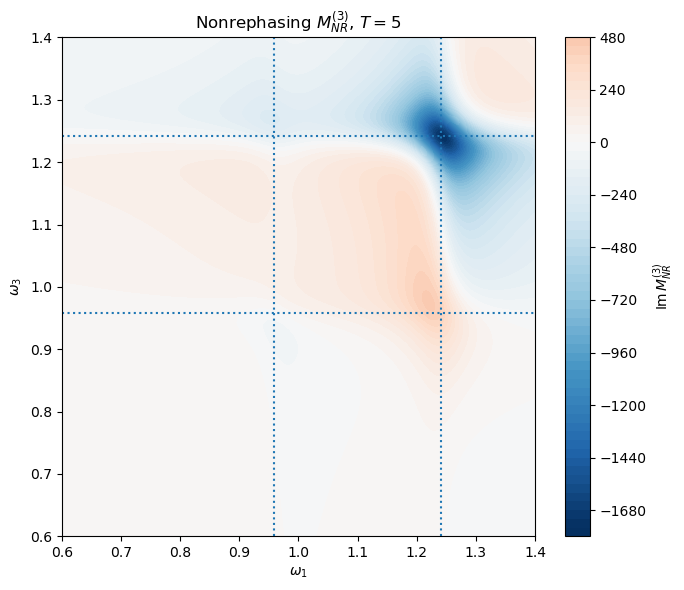

In [164]:
nr_limit = np.max(
    np.abs(
        np.imag(M3_NR)
    )
)

plt.figure(figsize=(7, 6))

plt.contourf(
    omega1_nr,
    omega3_rnr,
    np.imag(M3_NR),
    levels=60,
    vmin=-nr_limit,
    vmax=nr_limit,
    cmap="RdBu_r"
)

plt.colorbar(
    label=r"$\mathrm{Im}\,M_{NR}^{(3)}$"
)

plt.axvline(
    omega_minus,
    linestyle=":"
)

plt.axvline(
    omega_plus,
    linestyle=":"
)

plt.axhline(
    omega_minus,
    linestyle=":"
)

plt.axhline(
    omega_plus,
    linestyle=":"
)

plt.xlabel(r"$\omega_1$")
plt.ylabel(r"$\omega_3$")

plt.title(
    r"Nonrephasing $M_{NR}^{(3)}$, $T=5$"
)

plt.tight_layout()
plt.savefig(
    figures_dir / "third_order_impulsive_nonrephasing.pdf",
    bbox_inches="tight"
)

plt.show()
plt.show()

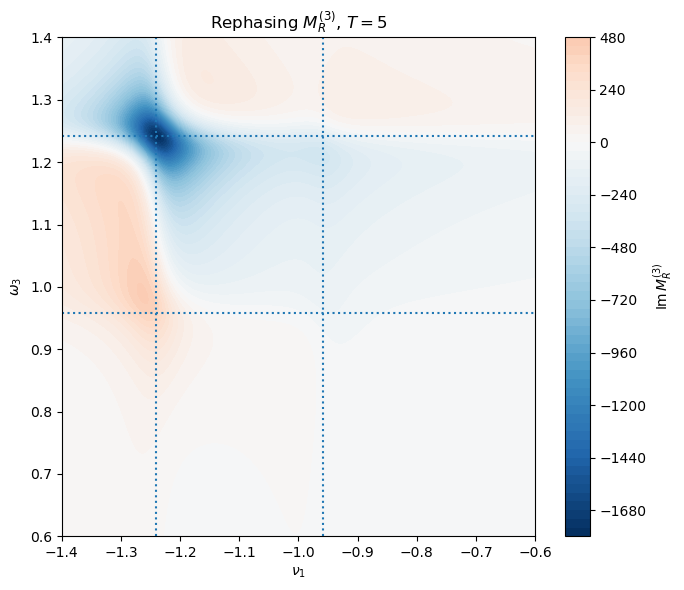

In [165]:
r_limit = np.max(
    np.abs(
        np.imag(M3_R)
    )
)

plt.figure(figsize=(7, 6))

plt.contourf(
    nu1_r,
    omega3_rnr,
    np.imag(M3_R),
    levels=60,
    vmin=-r_limit,
    vmax=r_limit,
    cmap="RdBu_r"
)

plt.colorbar(
    label=r"$\mathrm{Im}\,M_R^{(3)}$"
)

plt.axvline(
    -omega_minus,
    linestyle=":"
)

plt.axvline(
    -omega_plus,
    linestyle=":"
)

plt.axhline(
    omega_minus,
    linestyle=":"
)

plt.axhline(
    omega_plus,
    linestyle=":"
)

plt.xlabel(r"$\nu_1$")
plt.ylabel(r"$\omega_3$")

plt.title(
    r"Rephasing $M_R^{(3)}$, $T=5$"
)

plt.tight_layout()
plt.savefig(
    figures_dir / "third_order_impulsive_rephasing.pdf",
    bbox_inches="tight"
)

plt.show()
plt.show()

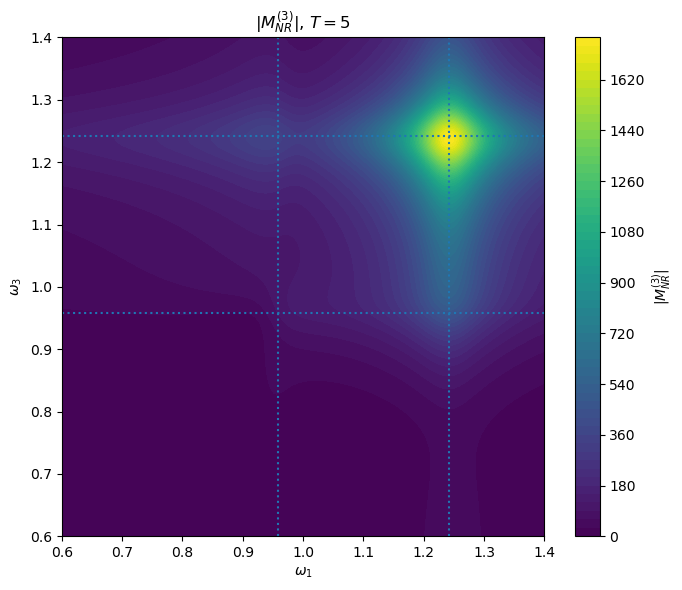

In [166]:
plt.figure(figsize=(7, 6))

plt.contourf(
    omega1_nr,
    omega3_rnr,
    np.abs(M3_NR),
    levels=60
)

plt.colorbar(
    label=r"$|M_{NR}^{(3)}|$"
)

plt.axvline(
    omega_minus,
    linestyle=":"
)

plt.axvline(
    omega_plus,
    linestyle=":"
)

plt.axhline(
    omega_minus,
    linestyle=":"
)

plt.axhline(
    omega_plus,
    linestyle=":"
)

plt.xlabel(r"$\omega_1$")
plt.ylabel(r"$\omega_3$")

plt.title(
    r"$|M_{NR}^{(3)}|$, $T=5$"
)

plt.tight_layout()
plt.show()

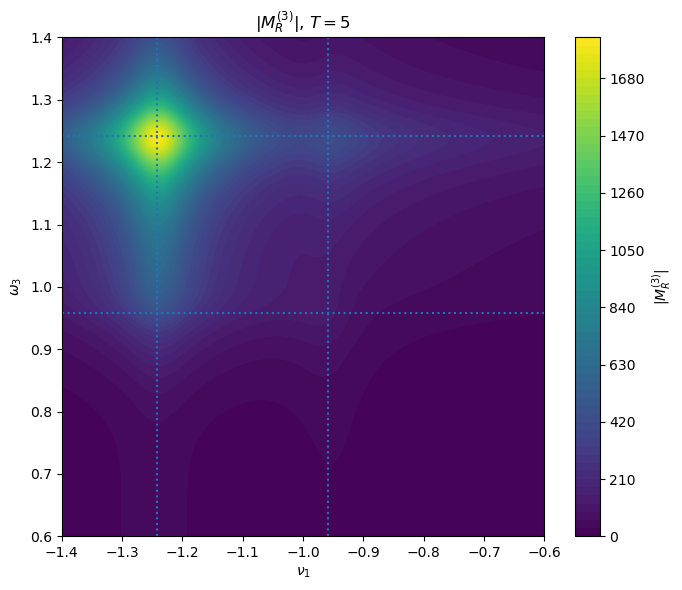

In [167]:
plt.figure(figsize=(7, 6))

plt.contourf(
    nu1_r,
    omega3_rnr,
    np.abs(M3_R),
    levels=60
)

plt.colorbar(
    label=r"$|M_R^{(3)}|$"
)

plt.axvline(
    -omega_minus,
    linestyle=":"
)

plt.axvline(
    -omega_plus,
    linestyle=":"
)

plt.axhline(
    omega_minus,
    linestyle=":"
)

plt.axhline(
    omega_plus,
    linestyle=":"
)

plt.xlabel(r"$\nu_1$")
plt.ylabel(r"$\omega_3$")

plt.title(
    r"$|M_R^{(3)}|$, $T=5$"
)

plt.tight_layout()
plt.show()

## 12. Full-dipole versus frequency-resolved detection

The positive phase-matched rephasing and nonrephasing branches considered
above both end in the $q=+1$ optical-coherence sector.

For nonrephasing,

$$
0
\xrightarrow{V_{\uparrow}}
+1
\xrightarrow{V_{\downarrow}}
0
\xrightarrow{V_{\uparrow}}
+1,
$$

whereas for rephasing,

$$
0
\xrightarrow{V_{\downarrow}}
-1
\xrightarrow{V_{\uparrow}}
0
\xrightarrow{V_{\uparrow}}
+1.
$$

The full dipole detection vector can be decomposed as

$$
\langle\!\langle\mu|
=
\langle\!\langle\mu_{\uparrow}|
+
\langle\!\langle\mu_{\downarrow}|.
$$

Because the final third-order state belongs to $q=+1$, the
$\mu_{\downarrow}$ Liouville bra cannot produce a scalar trace and its
contribution must vanish.  Therefore,

$$
\boxed{
\langle\!\langle\mu|
\rho_A^{(3)}
\rangle\rangle
=
\langle\!\langle\mu_{\uparrow}|
\rho_A^{(3)}
\rangle\rangle,
}
$$

while

$$
\boxed{
\langle\!\langle\mu_{\downarrow}|
\rho_A^{(3)}
\rangle\rangle
=
0.
}
$$

Here the label on the Liouville bra must be interpreted using the
Hilbert--Schmidt inner product,

$$
\langle\!\langle A|\rho\rangle\rangle
=
\operatorname{Tr}(A^\dagger\rho).
$$

Thus,

$$
\langle\!\langle\mu_{\uparrow}|\rho\rangle\rangle
=
\operatorname{Tr}(\mu_{\downarrow}\rho),
$$

which is the physical positive-frequency polarization generated by a
$q=+1$ optical coherence.

We now verify these relations numerically for both the rephasing and
nonrephasing spectra.

In [168]:
M3_NR_full = np.zeros_like(M3_NR)
M3_NR_up = np.zeros_like(M3_NR)
M3_NR_down = np.zeros_like(M3_NR)

for j, omega3 in enumerate(omega3_rnr):

    A3 = (
        (eta_rnr - 1j * omega3) * I16
        - L_super
    )

    X3 = np.linalg.solve(
        A3,
        source_for_G3_nr
    )

    # Full physical dipole readout
    M3_NR_full[j, :] = (
        mu_bra @ X3
    )

    # Positive-frequency Liouville-bra component
    M3_NR_up[j, :] = (
        mu_up_bra @ X3
    )

    # Conjugate Liouville-bra component
    M3_NR_down[j, :] = (
        mu_down_bra @ X3
    )

In [169]:
nr_decomposition_error = (
    norm(
        M3_NR_full
        - (
            M3_NR_up
            + M3_NR_down
        )
    )
    /
    norm(M3_NR_full)
)

nr_full_vs_up_error = (
    norm(
        M3_NR_full
        - M3_NR_up
    )
    /
    norm(M3_NR_full)
)

nr_unwanted_ratio = (
    np.max(np.abs(M3_NR_down))
    /
    np.max(np.abs(M3_NR_full))
)

print(
    "NR full-dipole decomposition error =",
    nr_decomposition_error
)

print(
    "NR full mu vs mu_up relative L2 error =",
    nr_full_vs_up_error
)

print(
    "NR max |mu_down contribution| / max |full| =",
    nr_unwanted_ratio
)

NR full-dipole decomposition error = 0.0
NR full mu vs mu_up relative L2 error = 0.0
NR max |mu_down contribution| / max |full| = 0.0


In [170]:
M3_R_full = np.zeros_like(M3_R)
M3_R_up = np.zeros_like(M3_R)
M3_R_down = np.zeros_like(M3_R)

for j, omega3 in enumerate(omega3_rnr):

    A3 = (
        (eta_rnr - 1j * omega3) * I16
        - L_super
    )

    X3 = np.linalg.solve(
        A3,
        source_for_G3_r
    )

    # Full physical dipole readout
    M3_R_full[j, :] = (
        mu_bra @ X3
    )

    # Positive-frequency Liouville-bra component
    M3_R_up[j, :] = (
        mu_up_bra @ X3
    )

    # Conjugate Liouville-bra component
    M3_R_down[j, :] = (
        mu_down_bra @ X3
    )

In [171]:
r_decomposition_error = (
    norm(
        M3_R_full
        - (
            M3_R_up
            + M3_R_down
        )
    )
    /
    norm(M3_R_full)
)

r_full_vs_up_error = (
    norm(
        M3_R_full
        - M3_R_up
    )
    /
    norm(M3_R_full)
)

r_unwanted_ratio = (
    np.max(np.abs(M3_R_down))
    /
    np.max(np.abs(M3_R_full))
)

print(
    "R full-dipole decomposition error =",
    r_decomposition_error
)

print(
    "R full mu vs mu_up relative L2 error =",
    r_full_vs_up_error
)

print(
    "R max |mu_down contribution| / max |full| =",
    r_unwanted_ratio
)

R full-dipole decomposition error = 0.0
R full mu vs mu_up relative L2 error = 0.0
R max |mu_down contribution| / max |full| = 0.0


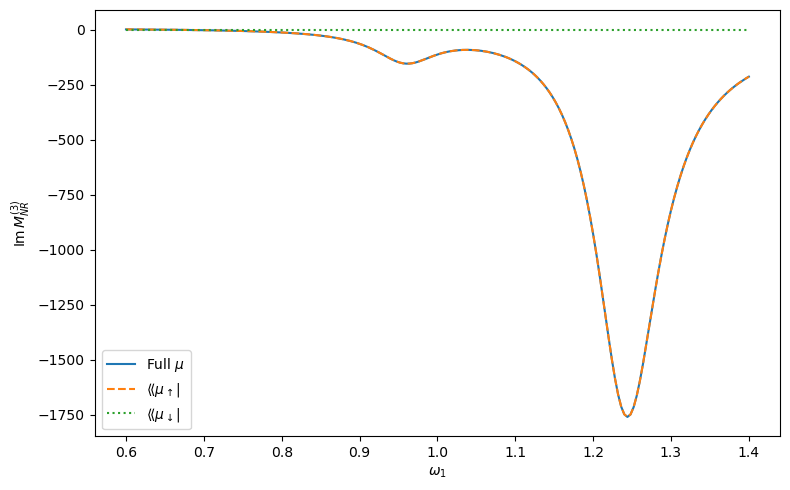

In [172]:
plt.figure(figsize=(8, 5))

j_nr_peak = np.argmin(
    np.abs(
        omega3_rnr
        - omega_plus
    )
)

plt.plot(
    omega1_nr,
    np.imag(M3_NR_full[j_nr_peak, :]),
    label=r"Full $\mu$"
)

plt.plot(
    omega1_nr,
    np.imag(M3_NR_up[j_nr_peak, :]),
    "--",
    label=r"$\langle\!\langle\mu_{\uparrow}|$"
)

plt.plot(
    omega1_nr,
    np.imag(M3_NR_down[j_nr_peak, :]),
    ":",
    label=r"$\langle\!\langle\mu_{\downarrow}|$"
)

plt.xlabel(r"$\omega_1$")
plt.ylabel(r"$\mathrm{Im}\,M_{NR}^{(3)}$")

plt.legend()
plt.tight_layout()
plt.show()

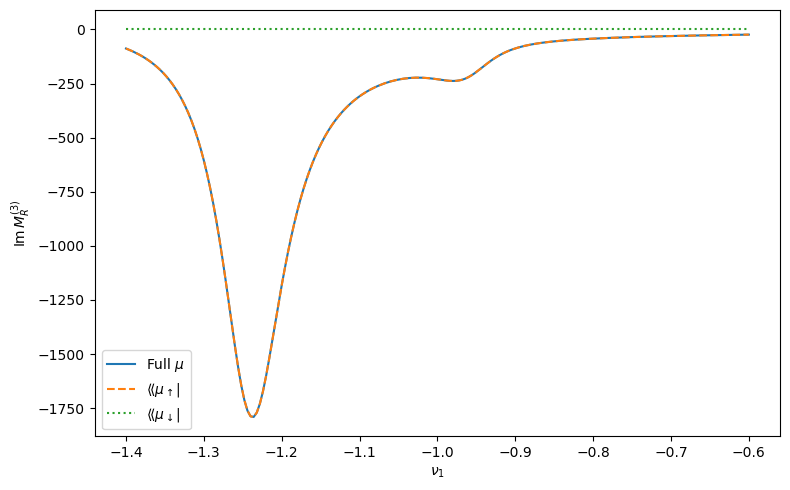

In [173]:
plt.figure(figsize=(8, 5))

j_r_peak = np.argmin(
    np.abs(
        omega3_rnr
        - omega_plus
    )
)

plt.plot(
    nu1_r,
    np.imag(M3_R_full[j_r_peak, :]),
    label=r"Full $\mu$"
)

plt.plot(
    nu1_r,
    np.imag(M3_R_up[j_r_peak, :]),
    "--",
    label=r"$\langle\!\langle\mu_{\uparrow}|$"
)

plt.plot(
    nu1_r,
    np.imag(M3_R_down[j_r_peak, :]),
    ":",
    label=r"$\langle\!\langle\mu_{\downarrow}|$"
)

plt.xlabel(r"$\nu_1$")
plt.ylabel(r"$\mathrm{Im}\,M_R^{(3)}$")

plt.legend()
plt.tight_layout()
plt.show()

## 13. External validation against QuDPy

The RWA-resolved rephasing and nonrephasing responses are now compared
against an independent time-domain calculation using QuDPy.

QuDPy propagates individual double-sided Feynman pathways rather than
the commutator superoperators used here.

For the lowering and raising dipoles,

$$
\mu = \mu_{\uparrow}+\mu_{\downarrow},
$$

the QuDPy ket/bra operations satisfy

$$
K_u\rho=\mu_{\uparrow}\rho,
\qquad
B_d\rho=\rho\mu_{\uparrow},
$$

and

$$
K_d\rho=\mu_{\downarrow}\rho,
\qquad
B_u\rho=\rho\mu_{\downarrow}.
$$

Therefore our RWA interaction superoperators can be written as

$$
V_{\uparrow}
=
i(K_u-B_d),
$$

and

$$
V_{\downarrow}
=
i(K_d-B_u),
$$

for $\hbar=1$.

For the ground-state initial condition used in this benchmark, the
standard QuDPy pathways reduce to

$$
\boxed{
R_R^{(3)}
=
i(R_3-R_1-R_2)
}
$$

for rephasing and

$$
\boxed{
R_{NR}^{(3)}
=
i(R_4-R_5-R_6)
}
$$

for nonrephasing.

QuDPy is used only for the explicit time-domain propagation.  Its
built-in FFT and plotting conventions are not used.  Instead, the
QuDPy time-domain responses are transformed below using exactly the
same damped Fourier convention employed in the direct-resolvent
calculation.

In [174]:
from pathlib import Path

qudpy_file = (
    repo_root
    / "data"
    / "qudpy_dimer_ground_td.npz"
)

qudpy_data = np.load(
    qudpy_file
)

print(
    "Loaded:",
    qudpy_file
)

print()
print(
    "Available arrays:"
)

for key in qudpy_data.files:
    value = qudpy_data[key]

    print(
        f"{key:10s}",
        np.shape(value)
    )

Loaded: /Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/data/qudpy_dimer_ground_td.npz

Available arrays:
t1         (400,)
t3         (400,)
responses  (6, 400, 400)
R1         (400, 400)
R2         (400, 400)
R3         (400, 400)
R4         (400, 400)
R5         (400, 400)
R6         (400, 400)
R          (400, 400)
NR         (400, 400)
T_wait     ()
tmax       ()
r          ()


In [175]:
t1_qd = qudpy_data["t1"]
t3_qd = qudpy_data["t3"]

R_qd_td = qudpy_data["R"]
NR_qd_td = qudpy_data["NR"]

R1_qd_td = qudpy_data["R1"]
R2_qd_td = qudpy_data["R2"]
R3_qd_td = qudpy_data["R3"]

R4_qd_td = qudpy_data["R4"]
R5_qd_td = qudpy_data["R5"]
R6_qd_td = qudpy_data["R6"]

print(
    "t1 range =",
    t1_qd[0],
    "to",
    t1_qd[-1]
)

print(
    "t3 range =",
    t3_qd[0],
    "to",
    t3_qd[-1]
)

print(
    "R shape =",
    R_qd_td.shape
)

print(
    "NR shape =",
    NR_qd_td.shape
)

print(
    "QuDPy T =",
    qudpy_data["T_wait"]
)

t1 range = 0.0 to 100.0
t3 range = 0.0 to 100.0
R shape = (400, 400)
NR shape = (400, 400)
QuDPy T = 5.0


### 13.1 Fourier transform of the QuDPy time-domain response

The QuDPy response arrays have the orientation

$$
R_{\mathrm{QD}}[i,j]
=
R_{\mathrm{QD}}(t_{1,i},t_{3,j}).
$$

Rather than using the built-in QuDPy FFT, the independently propagated
time-domain responses are transformed using the same damped causal
Fourier convention as the direct-resolvent calculation,

$$
M(\omega_3,T,\omega_1)
=
\int_0^\infty dt_3
\int_0^\infty dt_1\,
e^{(i\omega_3-\eta)t_3}
e^{(i\omega_1-\eta)t_1}
R(t_1,t_3).
$$

This removes any ambiguity associated with FFT sign conventions and
allows a direct comparison with the resolvent

$$
G_\eta(\omega)
=
\left[
(\eta-i\omega)I-\mathcal{L}
\right]^{-1}.
$$

In [176]:
dt1_qd = t1_qd[1] - t1_qd[0]
dt3_qd = t3_qd[1] - t3_qd[0]

trap1_qd = np.ones_like(t1_qd)
trap1_qd[[0, -1]] = 0.5
trap1_qd *= dt1_qd

trap3_qd = np.ones_like(t3_qd)
trap3_qd[[0, -1]] = 0.5
trap3_qd *= dt3_qd

print("dt1 =", dt1_qd)
print("dt3 =", dt3_qd)

print(
    "integrated t1 interval =",
    np.sum(trap1_qd)
)

print(
    "integrated t3 interval =",
    np.sum(trap3_qd)
)

dt1 = 0.2506265664160401
dt3 = 0.2506265664160401
integrated t1 interval = 99.99999999999997
integrated t3 interval = 99.99999999999997


In [177]:
W1_NR_qd = (
    np.exp(
        (
            1j * omega1_nr[:, None]
            - eta_rnr
        )
        * t1_qd[None, :]
    )
    * trap1_qd[None, :]
)

W3_qd = (
    np.exp(
        (
            1j * omega3_rnr[:, None]
            - eta_rnr
        )
        * t3_qd[None, :]
    )
    * trap3_qd[None, :]
)

In [178]:
W1_R_qd = (
    np.exp(
        (
            1j * nu1_r[:, None]
            - eta_rnr
        )
        * t1_qd[None, :]
    )
    * trap1_qd[None, :]
)

In [179]:
print(
    "W1 NR shape =",
    W1_NR_qd.shape
)

print(
    "W1 R shape =",
    W1_R_qd.shape
)

print(
    "W3 shape =",
    W3_qd.shape
)

W1 NR shape = (201, 400)
W1 R shape = (201, 400)
W3 shape = (201, 400)


In [180]:
M3_NR_qd = (
    W1_NR_qd
    @ NR_qd_td
    @ W3_qd.T
).T

In [181]:
M3_R_qd = (
    W1_R_qd
    @ R_qd_td
    @ W3_qd.T
).T

In [182]:
print(
    "QuDPy NR spectrum shape =",
    M3_NR_qd.shape
)

print(
    "QuDPy R spectrum shape =",
    M3_R_qd.shape
)

print(
    "QuDPy max |NR| =",
    np.max(np.abs(M3_NR_qd))
)

print(
    "QuDPy max |R| =",
    np.max(np.abs(M3_R_qd))
)

QuDPy NR spectrum shape = (201, 201)
QuDPy R spectrum shape = (201, 201)
QuDPy max |NR| = 1752.4596802542262
QuDPy max |R| = 1789.918288436989


### 13.2 Comparison with the direct resolvent

The QuDPy spectra are now compared directly with the RWA-resolved
frequency-domain resolvent calculation.

No amplitude normalization or phase adjustment is applied.  Agreement
must therefore include

- resonance positions,
- absolute magnitude,
- complex phase,
- and the full two-dimensional spectral structure.

### 13.2 Comparison with the direct resolvent

The QuDPy spectra are now compared directly with the RWA-resolved
frequency-domain resolvent calculation.

No amplitude normalization or phase adjustment is applied.  Agreement
must therefore include

- resonance positions,
- absolute magnitude,
- complex phase,
- and the full two-dimensional spectral structure.

In [183]:
# QuDPy nonrephasing peak
j_qd_nr, i_qd_nr = np.unravel_index(
    np.argmax(np.abs(M3_NR_qd)),
    M3_NR_qd.shape
)

# Resolvent nonrephasing peak
j_fd_nr, i_fd_nr = np.unravel_index(
    np.argmax(np.abs(M3_NR)),
    M3_NR.shape
)

# QuDPy rephasing peak
j_qd_r, i_qd_r = np.unravel_index(
    np.argmax(np.abs(M3_R_qd)),
    M3_R_qd.shape
)

# Resolvent rephasing peak
j_fd_r, i_fd_r = np.unravel_index(
    np.argmax(np.abs(M3_R)),
    M3_R.shape
)

In [184]:
print("NONREPHASING")
print()

print("QuDPy peak:")
print("omega_1 =", omega1_nr[i_qd_nr])
print("omega_3 =", omega3_rnr[j_qd_nr])
print("M_NR_QD =", M3_NR_qd[j_qd_nr, i_qd_nr])
print("|M_NR_QD| =", np.abs(M3_NR_qd[j_qd_nr, i_qd_nr]))

print()

print("Resolvent peak:")
print("omega_1 =", omega1_nr[i_fd_nr])
print("omega_3 =", omega3_rnr[j_fd_nr])
print("M_NR_FD =", M3_NR[j_fd_nr, i_fd_nr])
print("|M_NR_FD| =", np.abs(M3_NR[j_fd_nr, i_fd_nr]))

print()
print("--------------------------------")
print()

print("REPHASING")
print()

print("QuDPy peak:")
print("nu_1 =", nu1_r[i_qd_r])
print("omega_3 =", omega3_rnr[j_qd_r])
print("M_R_QD =", M3_R_qd[j_qd_r, i_qd_r])
print("|M_R_QD| =", np.abs(M3_R_qd[j_qd_r, i_qd_r]))

print()

print("Resolvent peak:")
print("nu_1 =", nu1_r[i_fd_r])
print("omega_3 =", omega3_rnr[j_fd_r])
print("M_R_FD =", M3_R[j_fd_r, i_fd_r])
print("|M_R_FD| =", np.abs(M3_R[j_fd_r, i_fd_r]))

NONREPHASING

QuDPy peak:
omega_1 = 1.244
omega_3 = 1.236
M_NR_QD = (-224.32008239949442-1738.043564341535j)
|M_NR_QD| = 1752.4596802542262

Resolvent peak:
omega_1 = 1.24
omega_3 = 1.236
M_NR_FD = (-370.17591846866526-1724.0225207137255j)
|M_NR_FD| = 1763.3161550165155

--------------------------------

REPHASING

QuDPy peak:
nu_1 = -1.24
omega_3 = 1.236
M_R_QD = (-387.24625386481966-1747.5261995600706j)
|M_R_QD| = 1789.918288436989

Resolvent peak:
nu_1 = -1.24
omega_3 = 1.24
M_R_FD = (-241.26011590633294-1787.3705687910976j)
|M_R_FD| = 1803.5797719279701


In [185]:
print("NR at resolvent peak location")
print("QuDPy    =", M3_NR_qd[j_fd_nr, i_fd_nr])
print("Resolvent =", M3_NR[j_fd_nr, i_fd_nr])
print(
    "QD / FD =",
    M3_NR_qd[j_fd_nr, i_fd_nr]
    / M3_NR[j_fd_nr, i_fd_nr]
)

print()

print("R at resolvent peak location")
print("QuDPy    =", M3_R_qd[j_fd_r, i_fd_r])
print("Resolvent =", M3_R[j_fd_r, i_fd_r])
print(
    "QD / FD =",
    M3_R_qd[j_fd_r, i_fd_r]
    / M3_R[j_fd_r, i_fd_r]
)

NR at resolvent peak location
QuDPy    = (-359.79776384876936-1715.0020830990145j)
Resolvent = (-370.17591846866526-1724.0225207137255j)
QD / FD = (0.9937628144067141+0.004680506557942844j)

R at resolvent peak location
QuDPy    = (-243.86402365753176-1772.5081336099033j)
Resolvent = (-241.26011590633294-1787.3705687910976j)
QD / FD = (0.9920266653792804-0.002533081536088985j)


### 13.3 Full two-dimensional QuDPy--resolvent agreement

The peak comparison shows agreement in resonance position, absolute
amplitude, and complex phase without normalization or phase adjustment.

We now quantify agreement over the complete two-dimensional spectra using

$$
\epsilon
=
\frac{
\left\|
M_{\mathrm{QD}}-M_{\mathrm{FD}}
\right\|_2
}{
\left\|
M_{\mathrm{FD}}
\right\|_2
}.
$$

Because the QuDPy calculation uses a finite time window and a relatively
coarse time grid, a small residual error is expected from truncation and
numerical quadrature rather than from the frequency-domain formulation.

In [186]:
err_NR_qd = (
    norm(M3_NR_qd - M3_NR)
    /
    norm(M3_NR)
)

err_R_qd = (
    norm(M3_R_qd - M3_R)
    /
    norm(M3_R)
)

print(
    "QuDPy vs resolvent NR relative L2 error =",
    err_NR_qd
)

print(
    "QuDPy vs resolvent R relative L2 error =",
    err_R_qd
)

QuDPy vs resolvent NR relative L2 error = 0.014516492946355784
QuDPy vs resolvent R relative L2 error = 0.014329111692375895


In [187]:
alpha_NR = (
    np.vdot(M3_NR, M3_NR_qd)
    /
    np.vdot(M3_NR, M3_NR)
)

alpha_R = (
    np.vdot(M3_R, M3_R_qd)
    /
    np.vdot(M3_R, M3_R)
)

print(
    "Best global complex factor NR =",
    alpha_NR
)

print(
    "Best global complex factor R =",
    alpha_R
)

Best global complex factor NR = (1.0074518368503782+0.0019405518978725088j)
Best global complex factor R = (1.0068793413434884-0.0020807395651632325j)


In [188]:
shape_err_NR = (
    norm(
        M3_NR_qd
        - alpha_NR * M3_NR
    )
    /
    norm(M3_NR_qd)
)

shape_err_R = (
    norm(
        M3_R_qd
        - alpha_R * M3_R
    )
    /
    norm(M3_R_qd)
)

print(
    "NR residual shape error =",
    shape_err_NR
)

print(
    "R residual shape error =",
    shape_err_R
)

NR residual shape error = 0.012213853356551686
R residual shape error = 0.012310659994374702


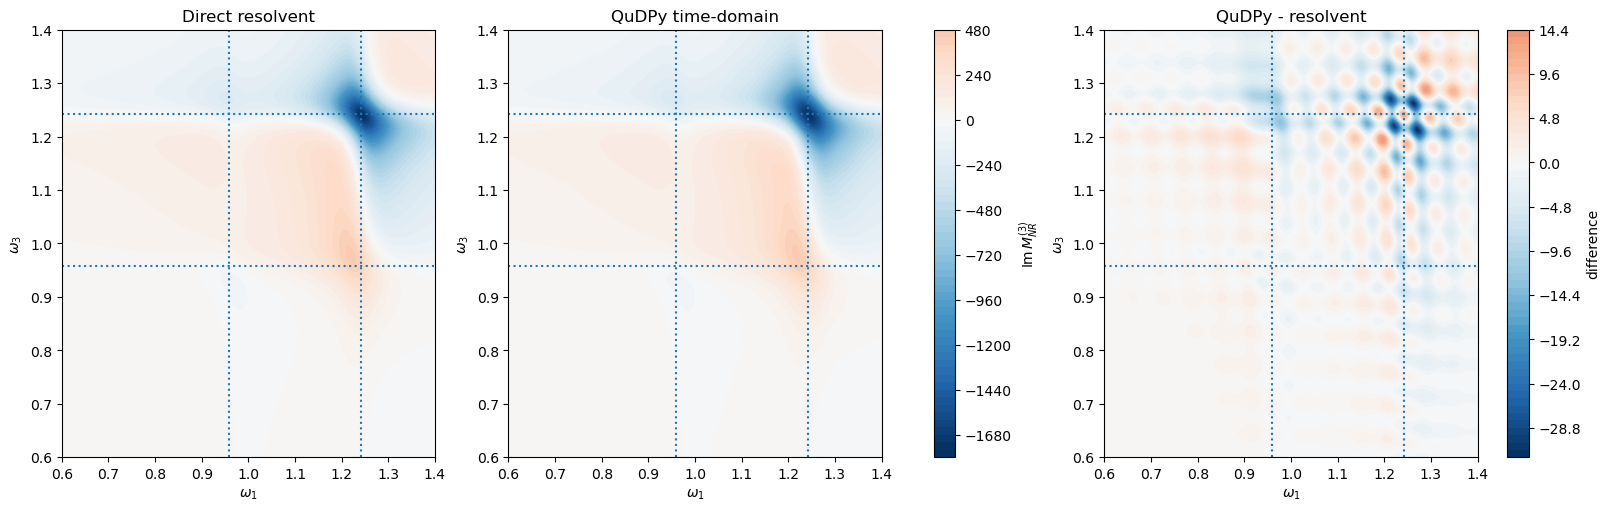

In [189]:
nr_vmax = max(
    np.max(np.abs(np.imag(M3_NR))),
    np.max(np.abs(np.imag(M3_NR_qd)))
)

nr_diff = (
    np.imag(M3_NR_qd)
    - np.imag(M3_NR)
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5),
    constrained_layout=True
)

im0 = axes[0].contourf(
    omega1_nr,
    omega3_rnr,
    np.imag(M3_NR),
    levels=60,
    vmin=-nr_vmax,
    vmax=nr_vmax,
    cmap="RdBu_r"
)

axes[0].set_title("Direct resolvent")

im1 = axes[1].contourf(
    omega1_nr,
    omega3_rnr,
    np.imag(M3_NR_qd),
    levels=60,
    vmin=-nr_vmax,
    vmax=nr_vmax,
    cmap="RdBu_r"
)

axes[1].set_title("QuDPy time-domain")

diff_vmax = np.max(
    np.abs(nr_diff)
)

im2 = axes[2].contourf(
    omega1_nr,
    omega3_rnr,
    nr_diff,
    levels=60,
    vmin=-diff_vmax,
    vmax=diff_vmax,
    cmap="RdBu_r"
)

axes[2].set_title("QuDPy - resolvent")

for ax in axes:

    ax.axvline(
        omega_minus,
        linestyle=":"
    )

    ax.axvline(
        omega_plus,
        linestyle=":"
    )

    ax.axhline(
        omega_minus,
        linestyle=":"
    )

    ax.axhline(
        omega_plus,
        linestyle=":"
    )

    ax.set_xlabel(r"$\omega_1$")
    ax.set_ylabel(r"$\omega_3$")

fig.colorbar(
    im0,
    ax=axes[:2],
    label=r"$\mathrm{Im}\,M_{NR}^{(3)}$"
)

fig.colorbar(
    im2,
    ax=axes[2],
    label="difference"
)
fig.savefig(
    figures_dir / "third_order_qudpy_nonrephasing_comparison.pdf",
    bbox_inches="tight"
)

plt.show()

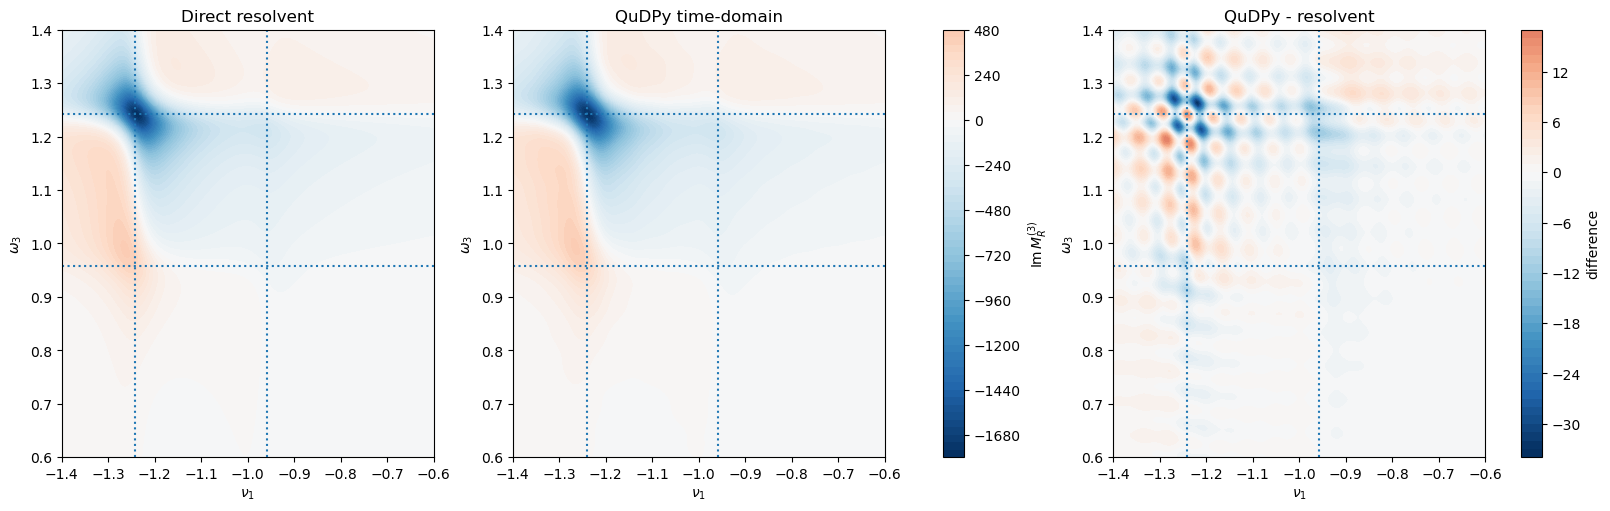

In [190]:
r_vmax = max(
    np.max(np.abs(np.imag(M3_R))),
    np.max(np.abs(np.imag(M3_R_qd)))
)

r_diff = (
    np.imag(M3_R_qd)
    - np.imag(M3_R)
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5),
    constrained_layout=True
)

im0 = axes[0].contourf(
    nu1_r,
    omega3_rnr,
    np.imag(M3_R),
    levels=60,
    vmin=-r_vmax,
    vmax=r_vmax,
    cmap="RdBu_r"
)

axes[0].set_title("Direct resolvent")

im1 = axes[1].contourf(
    nu1_r,
    omega3_rnr,
    np.imag(M3_R_qd),
    levels=60,
    vmin=-r_vmax,
    vmax=r_vmax,
    cmap="RdBu_r"
)

axes[1].set_title("QuDPy time-domain")

diff_vmax = np.max(
    np.abs(r_diff)
)

im2 = axes[2].contourf(
    nu1_r,
    omega3_rnr,
    r_diff,
    levels=60,
    vmin=-diff_vmax,
    vmax=diff_vmax,
    cmap="RdBu_r"
)

axes[2].set_title("QuDPy - resolvent")

for ax in axes:

    ax.axvline(
        -omega_minus,
        linestyle=":"
    )

    ax.axvline(
        -omega_plus,
        linestyle=":"
    )

    ax.axhline(
        omega_minus,
        linestyle=":"
    )

    ax.axhline(
        omega_plus,
        linestyle=":"
    )

    ax.set_xlabel(r"$\nu_1$")
    ax.set_ylabel(r"$\omega_3$")

fig.colorbar(
    im0,
    ax=axes[:2],
    label=r"$\mathrm{Im}\,M_R^{(3)}$"
)

fig.colorbar(
    im2,
    ax=axes[2],
    label="difference"
)
fig.savefig(
    figures_dir / "third_order_qudpy_rephasing_comparison.pdf",
    bbox_inches="tight"
)

plt.show()

### 13.4 QuDPy benchmark conclusion

The independently propagated QuDPy spectra agree quantitatively with
the direct frequency-domain resolvent calculation.

Using a finite QuDPy propagation window of $t_{\max}=100$ and a time
step of approximately $0.251$, the complete complex two-dimensional
spectra give relative errors

$$
\epsilon_{NR}
=
1.45\times10^{-2},
$$

and

$$
\epsilon_R
=
1.43\times10^{-2}.
$$

No amplitude normalization or phase correction is applied.

The best diagnostic global complex factors are close to unity,

$$
\alpha_{NR}
=
1.0075+0.0019i,
$$

$$
\alpha_R
=
1.0069-0.0021i,
$$

while the residual spectral-shape discrepancies are approximately
$1.2\%$ for both branches.

The agreement confirms the RWA interaction signs, the correspondence
between the commutator superoperators and the double-sided QuDPy
pathways, the rephasing/nonrephasing decomposition, and the direct
resolvent construction.